In [1]:
from astropy.io import fits
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
import pandas as pd

In [2]:
DP = DP()
dps_df, model_1comp_dps, left_2comp_dps, right_2comp_dps = DP.extract_fits_data('./catalogs/dps_classified.fits')

In [3]:
# incl_df = pd.read_csv('./catalogs/dp_catalog_with_inclination.csv')
# incl_df.head()

In [4]:
# dps_df = pd.merge(dps_df, incl_df, on='TARGETID', how='left')
# dps_df[~dps_df['incl'].isnull()].head()

In [5]:
stellar_df = pd.read_csv('./catalogs/stellar_fits_catalog.csv')
stellar_df.head()

,TARGETID,MORPHTYPE,SERSIC,SHAPE_R,VD_SL,incl
0,39627739380056154,DEV,4.000000,1.577094,145.330002,44.629128
1,39627739380056197,REX,1.000000,0.969577,78.970001,0.000000
2,39627739380056420,SER,0.722487,2.256895,2.770000,79.009950
3,39627739380056564,REX,1.000000,1.275339,59.770000,0.000000
4,39627739380056768,EXP,1.000000,3.253861,72.139999,78.399880


In [6]:
dps_df = pd.merge(dps_df, stellar_df, on='TARGETID', how='left',validate='one_to_one')
dps_df.head()

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,dv_r,dv_l,sigma_r,sigma_l,...,NII6583_rank,SII6716_rank,SII6731_rank,dp_count,BPT_class,MORPHTYPE,SERSIC,SHAPE_R,VD_SL,incl
0,39627739380056564,177.019318,-1.965308,0.323187,10.452706,0.941032,53.451893,-78.319199,50.218773,30.572901,...,1,7,9,2,512,REX,1.000000,1.275339,59.770000,0.000000
1,39627739380057506,177.058472,-1.984356,0.102379,10.324259,-0.880754,112.483803,-62.245144,42.930370,68.479820,...,1,4,6,1,512,REX,1.000000,0.781829,110.419998,0.000000
2,39627739380058467,177.097977,-1.888290,0.123931,10.402426,1.031611,88.860611,-27.739218,29.598230,52.082478,...,1,2,4,3,512,SER,1.144523,3.020720,86.650002,71.269295
3,39627739380060210,177.177948,-1.988386,0.238389,10.496312,0.039087,80.845169,-86.188843,52.286289,59.410812,...,1,2,5,2,512,SER,2.648419,1.265829,124.010002,47.433067
4,39627739380061198,177.216431,-1.948593,0.103277,9.514435,0.903058,88.226196,-73.512642,38.063850,50.911797,...,1,4,6,5,257,SER,1.779606,0.794439,100.040001,50.672260


In [7]:
print(len(dps_df))

25807


In [8]:
model_1comp_dps = model_1comp_dps[dps_df.index]
left_2comp_dps = left_2comp_dps[dps_df.index]
right_2comp_dps = right_2comp_dps[dps_df.index]

In [9]:
# spectra_data    = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
# cigale_data     = fits.open('/Users/hyp0515/data/IronPhysProp_v1.2_extracted.fits')
# fastspecfit     = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_fastspecfit.fits')
# DP_SPECTRA = Spectrum(spectra_data, cigale_data, fastspecfit, load_targetID=dps_df['TARGETID'].to_list())
# DP_SPECTRA = DP_SPECTRA.stack_data()
# DP_SPECTRA = DP_SPECTRA.shift_to_rest_frame()

In [10]:
delta_dv = dps_df['dv_r'] - dps_df['dv_l']
resolution = c * 0.8 / (Halpha_rest*(1+dps_df['Z']))
sigma_r = np.sqrt(dps_df['sigma_r']**2 + resolution**2)
sigma_l = np.sqrt(dps_df['sigma_l']**2 + resolution**2)
dps_df['delta_dv'] = delta_dv
dps_df['width_ratio'] = sigma_l / sigma_r


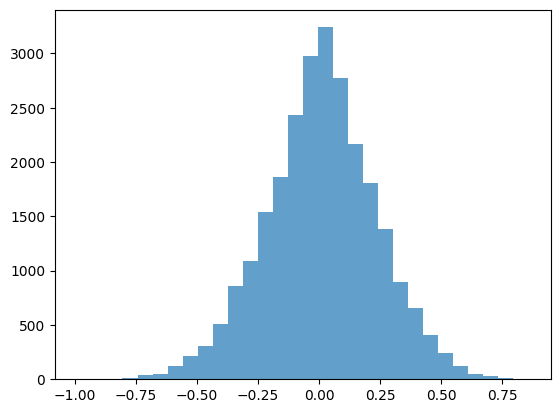

In [11]:
plt.hist(np.log10(dps_df['width_ratio']), bins=30, alpha=0.7, color='C0')
plt.show()

In [12]:
print(len(dps_df[np.log10(dps_df['width_ratio'])<0]))
print(len(dps_df[np.log10(dps_df['width_ratio'])>0]))

12271
13446


In [13]:
dps_df['flux_ratio'] = 0
for i in range(len(dps_df)):
    lam = desi_wavelength/(1+dps_df['Z'][i])
    left_shift = dps_df['dv_l'][i] / c * Halpha_rest[0]
    right_shift = dps_df['dv_r'][i] / c * Halpha_rest[0]

    left_flux = np.max(left_2comp_dps[i][(lam>(Halpha_rest[0]+left_shift-2)) & (lam<(Halpha_rest[0]+left_shift+2))])
    right_flux = np.max(right_2comp_dps[i][(lam>(Halpha_rest[0]+right_shift-2)) & (lam<(Halpha_rest[0]+right_shift+2))])

    if ((right_flux < 1) and (left_flux < 1)) or (dps_df['Halpha_dp'].iloc[i] is False):
        dps_df['flux_ratio'].iloc[i] = np.nan
    else:
        dps_df['flux_ratio'].iloc[i] = left_flux / right_flux


# dps_df['flux_ratio'] = 0
# for i in range(len(dps_df)):
#     lam = desi_wavelength/(1+dps_df['Z'][i])
#     left_shift = dps_df['dv_l'][i] / c * OIII_rest[1]
#     right_shift = dps_df['dv_r'][i] / c * OIII_rest[1]

#     left_flux = np.max(left_2comp_dps[i][(lam>(OIII_rest[1]+left_shift-2)) & (lam<(OIII_rest[1]+left_shift+2))])
#     right_flux = np.max(right_2comp_dps[i][(lam>(OIII_rest[1]+right_shift-2)) & (lam<(OIII_rest[1]+right_shift+2))])

#     if ((right_flux < 1) and (left_flux < 1)) or (dps_df['OIII5007_dp'].iloc[i] is False):
#         dps_df['flux_ratio'].iloc[i] = np.nan
#     else:
#         dps_df['flux_ratio'].iloc[i] = left_flux / right_flux



/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_42317/176573913.py:13: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  dps_df['flux_ratio'].iloc[i] = left_flux / right_flux
/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_

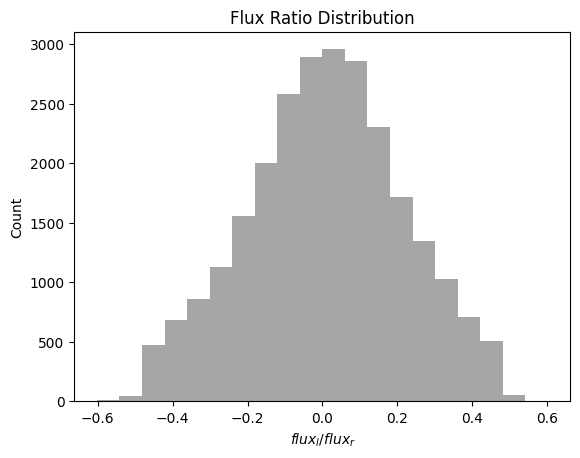

In [14]:
plt.hist(np.log10(dps_df['flux_ratio']), bins=20, color='gray', alpha=0.7,range=(np.log10(1/4), np.log10(4)))
plt.xlabel(r'$flux_l/flux_r$')
plt.ylabel('Count')
# plt.xscale('log')
# plt.yscale('log')
plt.title('Flux Ratio Distribution')
plt.show()

In [15]:
print(len(dps_df[np.log10(dps_df['flux_ratio'])<0]))
print(len(dps_df[np.log10(dps_df['flux_ratio'])>0]))

12269
13527


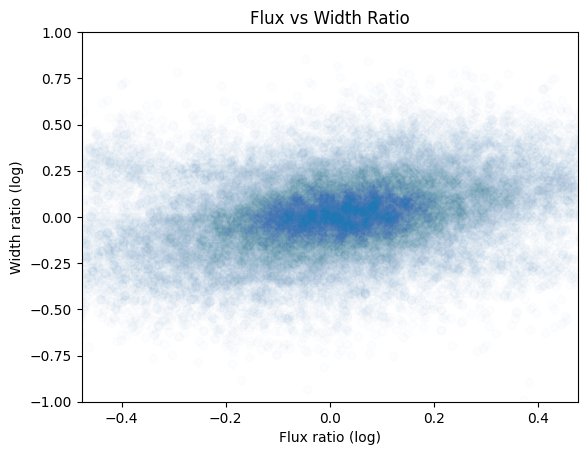

In [16]:
# plt.scatter(np.abs(np.log10(dps_df['flux_ratio'])), np.abs(np.log10(dps_df['width_ratio'])), alpha=.01)
plt.scatter((np.log10(dps_df['flux_ratio'])), (np.log10(dps_df['width_ratio'])), alpha=.01)
# plt.axvline(np.log10(1.3), color='k', linestyle='--', linewidth=1)
# plt.axhline(np.log10(1.5), color='k', linestyle='--', linewidth=1)
plt.xlim(left=np.log10(1/3), right=np.log10(3))
plt.ylim(bottom=np.log10(1/10), top=np.log10(10))
plt.title('Flux vs Width Ratio')
plt.xlabel('Flux ratio (log)')
plt.ylabel('Width ratio (log)')
plt.savefig('./figures/Feb6/flux_width_ratio.png')
plt.show()

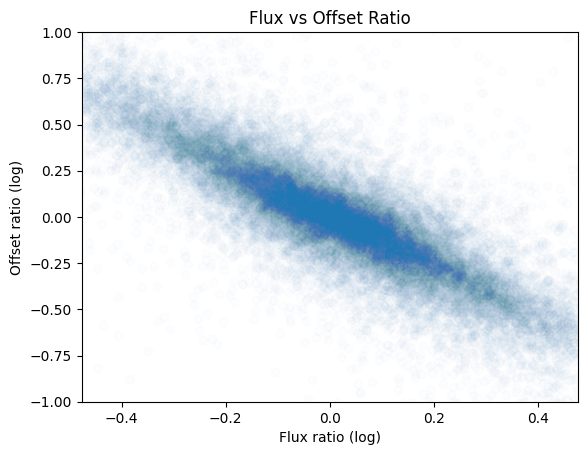

In [17]:
# plt.scatter(np.abs(np.log10(dps_df['flux_ratio'])), np.abs(np.log10(-dps_df['dv_l']/(dps_df['dv_r']))), alpha=.01)
plt.scatter((np.log10(dps_df['flux_ratio'])), (np.log10(-dps_df['dv_l']/(dps_df['dv_r']))), alpha=.01)
# plt.axvline(np.log10(1.3), color='k', linestyle='--', linewidth=1)
# plt.axhline(np.log10(2), color='k', linestyle='--', linewidth=1)
plt.ylim(bottom=-1, top=1)
plt.xlim(left=np.log10(1/3), right=np.log10(3))
plt.title('Flux vs Offset Ratio')
plt.xlabel('Flux ratio (log)')
plt.ylabel('Offset ratio (log)')
plt.savefig('./figures/Feb6/flux_offset_ratio.png')
plt.show()

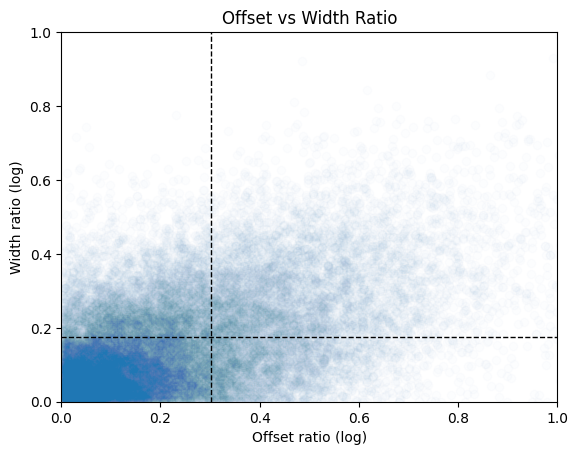

In [18]:
plt.scatter(np.abs(np.log10(-dps_df['dv_l']/(dps_df['dv_r']))), np.abs(np.log10(dps_df['width_ratio'])), alpha=0.01)
# plt.scatter((np.log10(-dps_df['dv_l']/(dps_df['dv_r']))), (np.log10(dps_df['width_ratio'])), alpha=0.01)
plt.axvline(np.log10(2), color='k', linestyle='--', linewidth=1)
plt.axhline(np.log10(1.5), color='k', linestyle='--', linewidth=1)
plt.xlim(left=0, right=1)
plt.ylim(bottom=0, top=1)
plt.title('Offset vs Width Ratio')
plt.xlabel('Offset ratio (log)')
plt.ylabel('Width ratio (log)')
plt.savefig('./figures/Feb6/offset_width_ratio_abs.png')
plt.show()

In [19]:
print(len(dps_df[np.log10(-dps_df['dv_l']/(dps_df['dv_r']))<0]))
print(len(dps_df[np.log10(-dps_df['dv_l']/(dps_df['dv_r']))>0]))

13059
12748


In [20]:
def extract_symmetry(df, flux=None, width=None, offset=None):
    combine_crit = np.ones(len(df), dtype=bool)
    
    if flux is True:
        # flux_crit = np.abs(np.log10(df['flux_ratio']))<np.log10(1.3)
        combine_crit &= np.abs(np.log10(df['flux_ratio']))<np.log10(1.3)
    elif flux is False:
        combine_crit &=  np.abs(np.log10(df['flux_ratio']))>=np.log10(1.3)
    elif flux is None:
        pass

    if width is True:
        combine_crit &= np.abs(np.log10(df['width_ratio']))<np.log10(1.5)
    elif width is False:
        combine_crit &= np.abs(np.log10(df['width_ratio']))>=np.log10(1.5)
    elif width is None:
        pass

    if offset is True:
        combine_crit &= np.abs(np.log10(-df['dv_l']/(df['dv_r'])))<np.log10(2)
    elif offset is False:
        combine_crit &= np.abs(np.log10(-df['dv_l']/(df['dv_r'])))>=np.log10(2)
    elif offset is None:
        pass

    return df[combine_crit]


In [21]:
classification_map_2comp = {
    2: 'double SF', 8: 'double COMP', 32: 'double AGN', 128: 'double LINER',
    5: 'SF+COMP', 17: 'SF+AGN', 65: 'SF+LINER',
    20: 'COMP+AGN', 68: 'COMP+LINER', 80: 'AGN+LINER',
    257: 'SF+uncertain', 260: 'COMP+uncertain', 272: 'AGN+uncertain', 320: 'LINER+uncertain',
    512: 'unclassified'
}

In [22]:
dps_df['BPT_class_str'] = dps_df['BPT_class'].map(classification_map_2comp)

In [23]:
sWsO = extract_symmetry(dps_df, flux=None, width=True, offset=True)
sWsO.head(5)

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,dv_r,dv_l,sigma_r,sigma_l,...,BPT_class,MORPHTYPE,SERSIC,SHAPE_R,VD_SL,incl,delta_dv,width_ratio,flux_ratio,BPT_class_str
0,39627739380056564,177.019318,-1.965308,0.323187,10.452706,0.941032,53.451893,-78.319199,50.218773,30.572901,...,512,REX,1.000000,1.275339,59.770000,0.000000,131.771088,0.718833,0.967905,unclassified
1,39627739380057506,177.058472,-1.984356,0.102379,10.324259,-0.880754,112.483803,-62.245144,42.930370,68.479820,...,512,REX,1.000000,0.781829,110.419998,0.000000,174.728943,1.402761,1.200418,unclassified
3,39627739380060210,177.177948,-1.988386,0.238389,10.496312,0.039087,80.845169,-86.188843,52.286289,59.410812,...,512,SER,2.648419,1.265829,124.010002,47.433067,167.034012,1.104896,0.857593,unclassified
4,39627739380061198,177.216431,-1.948593,0.103277,9.514435,0.903058,88.226196,-73.512642,38.063850,50.911797,...,257,SER,1.779606,0.794439,100.040001,50.672260,161.738831,1.203787,1.090860,SF+uncertain
5,39627739380062010,177.248581,-1.948161,0.123900,10.082528,0.143419,43.848770,-52.143093,46.679775,53.761292,...,512,SER,0.511738,2.404789,0.000000,68.051020,95.991867,1.104456,0.871091,unclassified


In [24]:
print(sWsO['BPT_class_str'].value_counts())

BPT_class_str
unclassified      4903
double SF         3343
SF+uncertain      2368
SF+COMP            264
COMP+uncertain     176
AGN+uncertain      163
double COMP        117
SF+AGN             116
double AGN          78
COMP+AGN            76
COMP+LINER           2
AGN+LINER            1
Name: count, dtype: int64


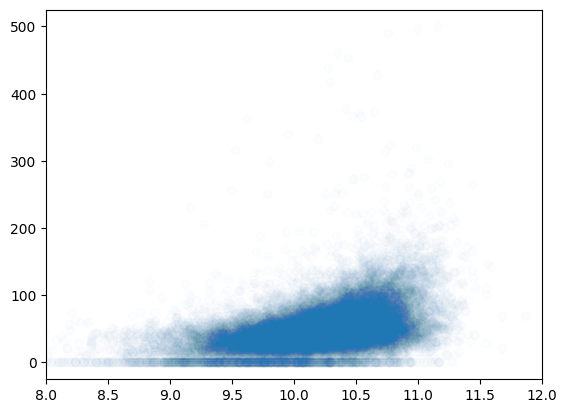

In [25]:
plt.scatter(dps_df['LOGM'], (dps_df['sigma_r']), alpha=0.01)
plt.xlim(left=8, right=12)
plt.show()

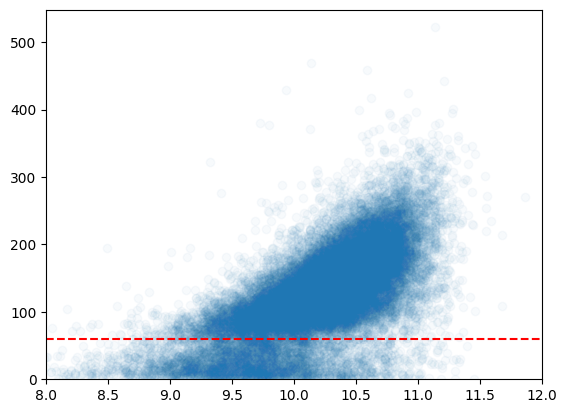

In [26]:
plt.scatter(dps_df['LOGM'], (dps_df['delta_dv']), alpha=0.03)
plt.axhline(60, color='r', linestyle='--')
plt.xlim(left=8, right=12)
plt.ylim(bottom=0)
plt.show()

In [27]:
print(dps_df[dps_df['delta_dv']<60]['BPT_class_str'].value_counts())

BPT_class_str
double SF          1437
SF+uncertain       1335
unclassified        496
SF+AGN              263
SF+COMP             215
COMP+uncertain      152
AGN+uncertain       133
double AGN           24
COMP+AGN             19
double COMP          17
AGN+LINER             2
SF+LINER              1
LINER+uncertain       1
Name: count, dtype: int64


In [28]:
print(dps_df[dps_df['delta_dv']>60]['BPT_class_str'].value_counts())

BPT_class_str
unclassified       10854
SF+uncertain        4611
double SF           4381
COMP+uncertain       445
AGN+uncertain        439
SF+COMP              390
double AGN           172
double COMP          162
COMP+AGN             125
SF+AGN               123
LINER+uncertain        5
AGN+LINER              3
COMP+LINER             2
Name: count, dtype: int64


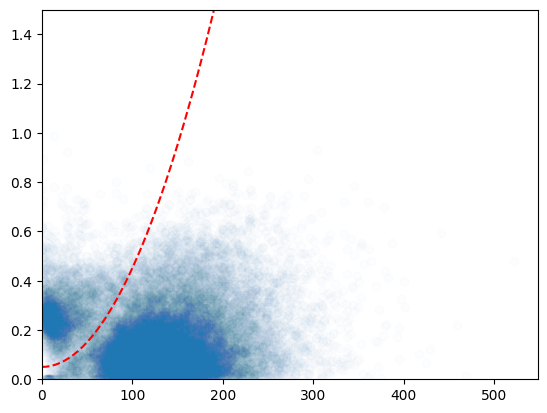

In [29]:
x = np.linspace(0, 500, 100)
y = 4e-5 * x**2 + 0.05

plt.scatter(dps_df['delta_dv'], np.abs(np.log10(dps_df['width_ratio'])), alpha=0.01)
plt.plot(x, y, color='r', linestyle='--')
# plt.axvline(60, color='r', linestyle='--')
# plt.axhline(0.1, color='r', linestyle='--')
plt.xlim(left=0)
plt.ylim(bottom=0, top=1.5)
plt.show()

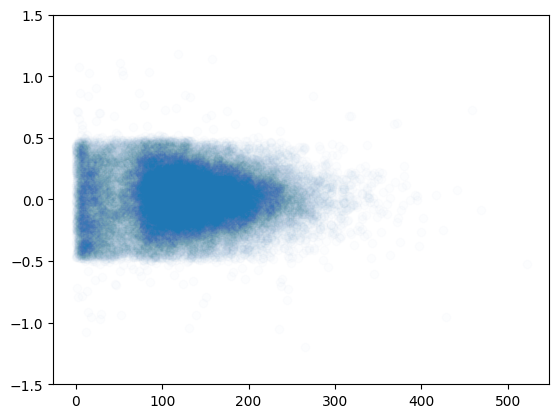

In [30]:
plt.scatter(dps_df['delta_dv'], np.log10(dps_df['flux_ratio']), alpha=0.01)
plt.ylim(bottom=-1.5, top=1.5)
plt.show()

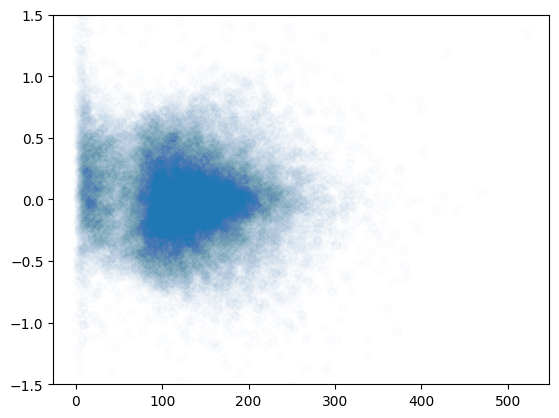

In [31]:
plt.scatter(dps_df['delta_dv'], np.log10(-dps_df['dv_l']/(dps_df['dv_r'])), alpha=0.01)
plt.ylim(bottom=-1.5, top=1.5)
plt.show()

In [32]:

robust_dps = dps_df[(dps_df['BPT_class_str']!='unclassified')&(~dps_df['incl'].isnull())&(dps_df['dp_count']>1)&(dps_df['VD_SL']!=0)&(dps_df['LOGM']!=0)]
robust_dps = robust_dps[(~robust_dps['width_ratio'].isnull())&(~robust_dps['flux_ratio'].isnull())]
robust_dps.sort_values(['width_ratio'], ascending=True).head(5)

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,dv_r,dv_l,sigma_r,sigma_l,...,BPT_class,MORPHTYPE,SERSIC,SHAPE_R,VD_SL,incl,delta_dv,width_ratio,flux_ratio,BPT_class_str
14952,39627788117870255,202.074509,0.018202,0.170708,11.051802,-2.796699,6.262650,-166.077087,153.532928,5.852295,...,20,SER,4.628341,2.882978,250.559998,69.928200,172.339737,0.202658,0.571721,COMP+AGN
8245,39627769591634010,177.994232,-0.778128,0.142334,9.492795,1.348116,42.087078,-6.557887,256.091095,41.436226,...,32,SER,1.940222,0.695595,26.400000,57.195090,48.644966,0.202818,1.996868,double AGN
18105,39627799958392368,187.911758,0.520320,0.406876,11.231089,-3.629425,18.858974,-137.894257,139.626801,13.135848,...,260,REX,1.000000,0.763807,108.430000,0.000000,156.753235,0.204911,0.479690,COMP+uncertain
13856,39627782392648493,220.937439,-0.250674,0.140990,10.492545,1.070695,6.241137,-39.239338,169.478729,15.609603,...,32,SER,2.866763,2.129077,129.220001,38.560295,45.480476,0.206532,0.206464,double AGN
3056,39627751598066551,185.373505,-1.531089,0.282807,11.313957,-2.605330,24.101505,-109.280045,177.278381,25.953163,...,272,SER,3.332538,2.526895,389.959991,36.096940,133.381546,0.214598,0.397161,AGN+uncertain


In [33]:
print(len(robust_dps))

10287


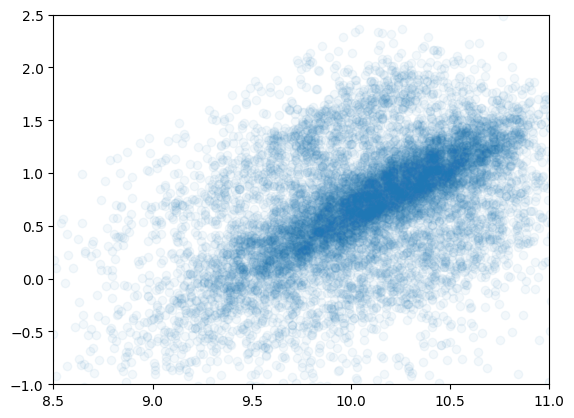

In [34]:
x = np.linspace(8, 12, 100)
y = -9 + 0.9 * x

plt.scatter(robust_dps['LOGM'], robust_dps['LOGSFR'], alpha=0.05)
plt.ylim((-1, 2.5))
plt.xlim((8.5, 11))
# plt.plot(x, y+0.6, color='r', linestyle='--', label='MS: LOGSFR = -9 + 0.9 * LOGM')
# plt.plot(x, y+0.9, color='r', linestyle=':')
# plt.plot(x, y+0.3, color='r', linestyle=':')
# plt.plot(x, y+1.2, color='gray', linestyle='--')
# plt.legend()
plt.show()

In [35]:
logm_bin_bound = np.linspace(8.5, 11, 7, endpoint=True)
logsfr_bin_bound = np.linspace(-1, 2.5, 7, endpoint=True)

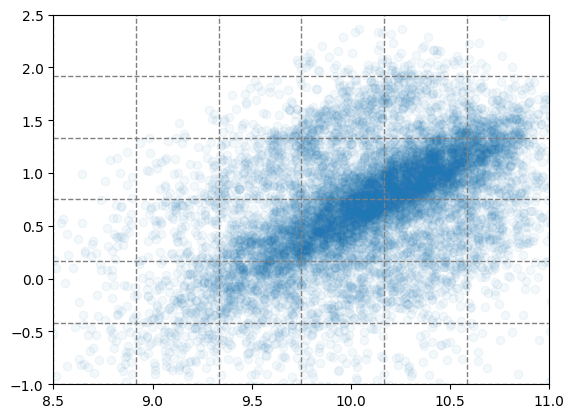

In [36]:

plt.scatter(robust_dps['LOGM'], robust_dps['LOGSFR'], alpha=0.05)
for i in range(len(logm_bin_bound)-1):
    plt.axvline(logm_bin_bound[i], color='gray', linestyle='--', linewidth=1)
for j in range(len(logsfr_bin_bound)-1):
    plt.axhline(logsfr_bin_bound[j], color='gray', linestyle='--', linewidth=1)
plt.ylim((-1, 2.5))
plt.xlim((8.5, 11))
# plt.legend()
plt.show()

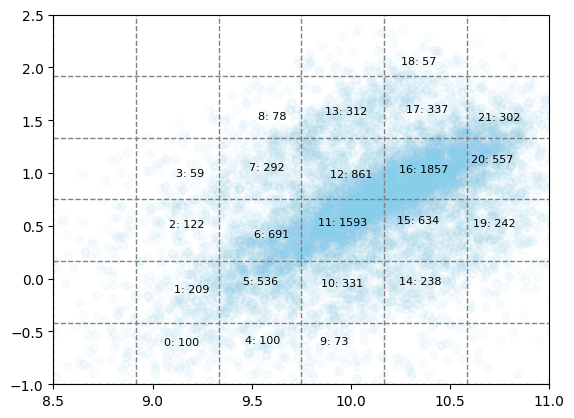

In [37]:

plt.scatter(robust_dps['LOGM'], robust_dps['LOGSFR'], alpha=0.05, color='skyblue')
for i in range(len(logm_bin_bound)-1):
    plt.axvline(logm_bin_bound[i], color='gray', linestyle='--', linewidth=1)
for j in range(len(logsfr_bin_bound)-1):
    plt.axhline(logsfr_bin_bound[j], color='gray', linestyle='--', linewidth=1)

bin_num = 0
bin_dps_list = []
for i in range(len(logm_bin_bound)-1):
    for j in range(len(logsfr_bin_bound)-1):
        bin_dps = robust_dps[(robust_dps['LOGM']>=logm_bin_bound[i]) & (robust_dps['LOGM']<logm_bin_bound[i+1]) & (robust_dps['LOGSFR']>=logsfr_bin_bound[j]) & (robust_dps['LOGSFR']<logsfr_bin_bound[j+1])]
        # print(f'Bin LOGM: [{logm_bin_bound[i]:.2f}, {logm_bin_bound[i+1]:.2f}), LOGSFR: [{logsfr_bin_bound[j]:.2f}, {logsfr_bin_bound[j+1]:.2f}), Count: {len(bin_dps)}')
        # plt.scatter(bin_dps['LOGM'], bin_dps['LOGSFR'], alpha=0.1, color='skyblue')
        if len(bin_dps)>50:
            bin_dps_list.append(bin_dps)
            plt.text(bin_dps['LOGM'].mean(), bin_dps['LOGSFR'].mean(), f'{bin_num}: {len(bin_dps)}', fontsize=8, ha='center')
            bin_num += 1

plt.ylim((-1, 2.5))
plt.xlim((8.5, 11))
plt.show()   

In [38]:
logm_group = [[0, 1, 2, 3], [4, 5, 6, 7, 8], [9, 10, 11, 12, 13], [14, 15, 16, 17, 18], [19, 20, 21]]
logm_bin = [9, 9.5, 10, 10.5, 11]

logsfr_group = [[0, 4, 9], [1, 5, 10, 14], [2, 6, 11, 15, 19], [3, 7, 12, 16, 20], [8, 13, 17, 21], [18]]
logsfr_bin = [-0.5, 0.0, 0.5, 1.0, 1.5, 2]

In [39]:
# colors = ['C0', 'C1', 'C2', 'C3', 'C4']
# for i, subgroup in enumerate(logm_group):
#     for bin_idx in subgroup:
#         bin_dps = bin_dps_list[bin_idx]
#         for j in range(len(logsfr_group)):
#             if bin_idx in logsfr_group[j]:
#                 plt.scatter(logsfr_bin[j], bin_dps['delta_dv'].mean(), color=colors[i])
#                 # plt.errorbar(logsfr_bin[j], bin_dps['delta_dv'].mean(), yerr=bin_dps['delta_dv'].std(), color=colors[i])
# plt.show()

In [40]:
# colors = ['C0', 'C1', 'C2', 'C3', 'C4']
# for i, subgroup in enumerate(logm_group):
#     for bin_idx in subgroup:
#         bin_dps = bin_dps_list[bin_idx]
#         for j in range(len(logsfr_group)):
#             if bin_idx in logsfr_group[j]:
#                 plt.scatter(logsfr_bin[j], bin_dps['VD_SL'].mean(), color=colors[i])
# plt.show()

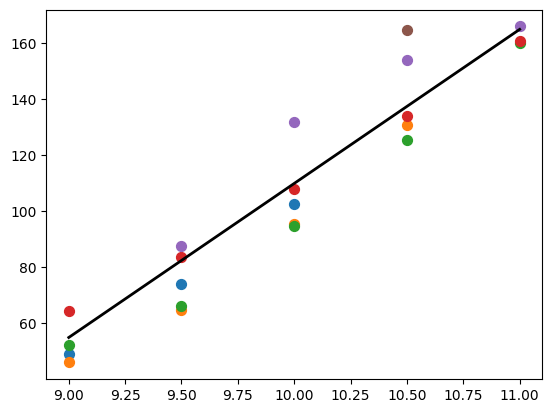

In [41]:
colors = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5']
for i, subgroup in enumerate(logsfr_group):
    for bin_idx in subgroup:
        bin_dps = bin_dps_list[bin_idx]
        for j in range(len(logm_group)):
            if bin_idx in logm_group[j]:
                plt.scatter(logm_bin[j], bin_dps['delta_dv'].mean(), color=colors[i], s=50)

x = np.linspace(9, 11, 100)
y = 55*(x-9)+55
plt.plot(x, y, color='black', lw=2)
plt.show()

In [42]:
# colors = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5']
# for i, subgroup in enumerate(logsfr_group):
#     for bin_idx in subgroup:
#         bin_dps = bin_dps_list[bin_idx]
#         for j in range(len(logm_group)):
#             if bin_idx in logm_group[j]:
#                 plt.scatter(logm_bin[j], bin_dps['VD_SL'].mean(), color=colors[i])
# plt.show()

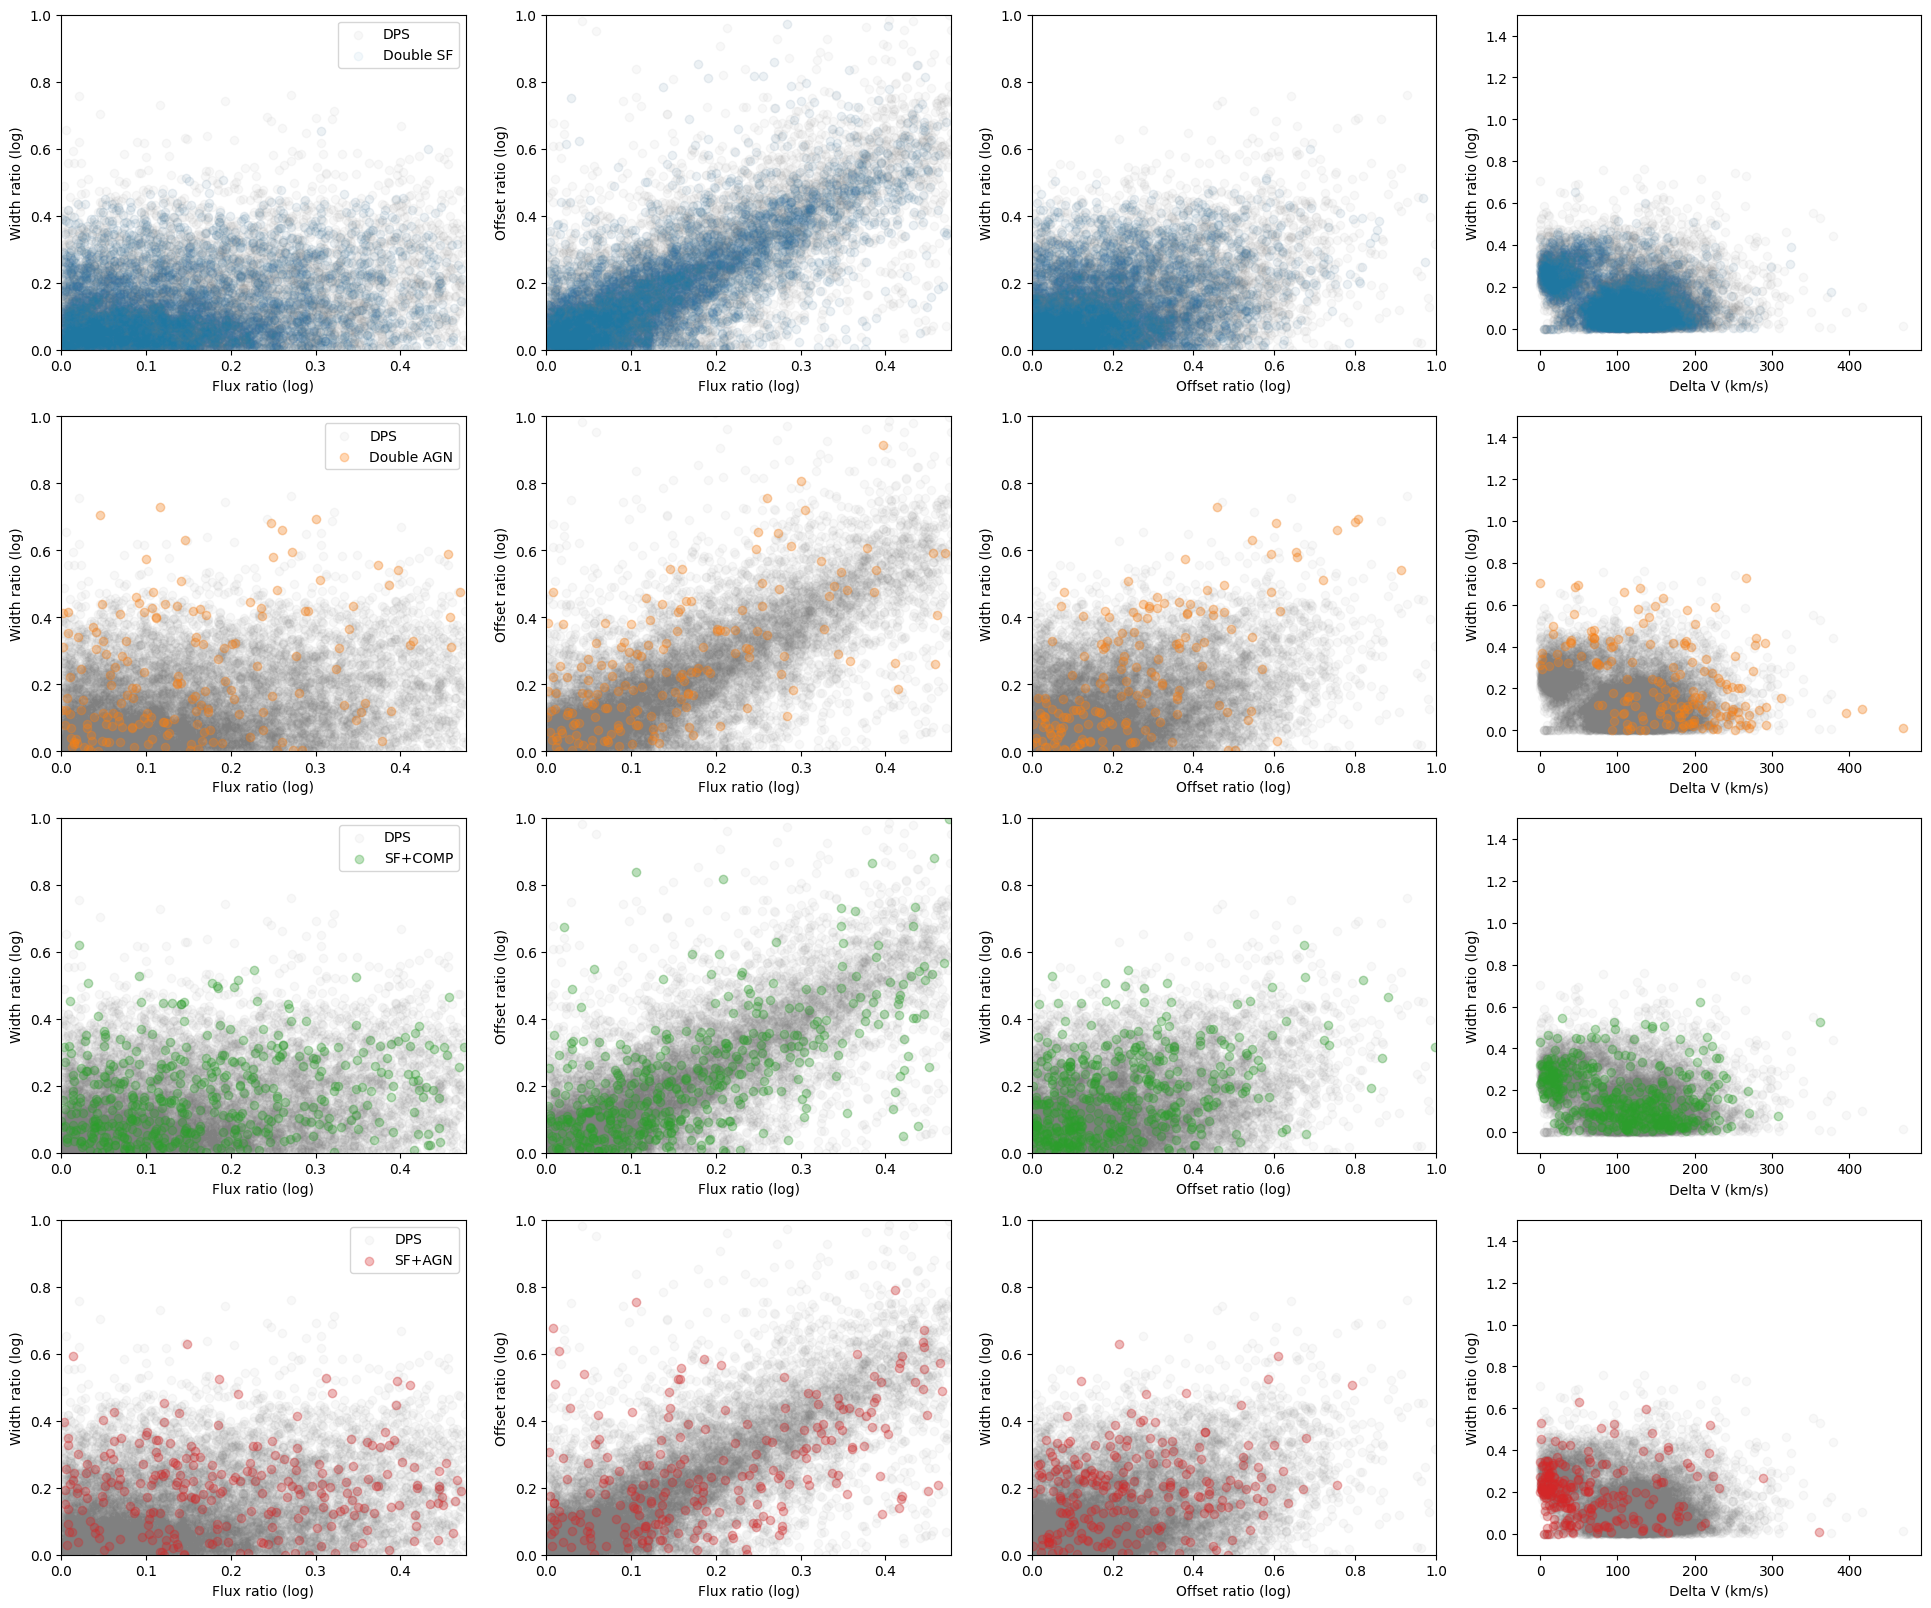

In [43]:

dSF = robust_dps[robust_dps['BPT_class_str']=='double SF'].copy()
dAGN = robust_dps[robust_dps['BPT_class_str']=='double AGN'].copy()
SF_COMP = robust_dps[robust_dps['BPT_class_str']=='SF+COMP'].copy()
SF_AGN = robust_dps[robust_dps['BPT_class_str']=='SF+AGN'].copy()

fig, axes = plt.subplots(4, 4, figsize=(24, 20))

labels = ['Double SF', 'Double AGN', 'SF+COMP', 'SF+AGN']
colors = ['C0', 'C1', 'C2', 'C3']
for i, subset in enumerate([dSF, dAGN, SF_COMP, SF_AGN]):
    ax = axes[i]
    ax[0].scatter(np.abs(np.log10(robust_dps['flux_ratio'])), np.abs(np.log10(robust_dps['width_ratio'])), alpha=.05, color='gray', label='DPS')
    ax[0].scatter(np.abs(np.log10(subset['flux_ratio'])), np.abs(np.log10(subset['width_ratio'])), alpha=.3 if i!=0 else 0.05, color=colors[i], label=labels[i])
    ax[0].set_xlim(left=0, right=np.log10(3))
    ax[0].set_ylim(bottom=0, top=np.log10(10))
    ax[0].set_xlabel('Flux ratio (log)')
    ax[0].set_ylabel('Width ratio (log)')
    ax[0].legend()


    ax[1].scatter(np.abs(np.log10(robust_dps['flux_ratio'])), np.abs(np.log10(-robust_dps['dv_l']/(robust_dps['dv_r']))), alpha=.05, color='gray', label='DPS')
    ax[1].scatter(np.abs(np.log10(subset['flux_ratio'])), np.abs(np.log10(-subset['dv_l']/(subset['dv_r']))), alpha=.3 if i!=0 else 0.05, color=colors[i], label=labels[i])
    ax[1].set_ylim(bottom=0, top=1)
    ax[1].set_xlim(left=0, right=np.log10(3))
    ax[1].set_xlabel('Flux ratio (log)')
    ax[1].set_ylabel('Offset ratio (log)')

    ax[2].scatter(np.abs(np.log10(-robust_dps['dv_l']/(robust_dps['dv_r']))), np.abs(np.log10(robust_dps['width_ratio'])), alpha=0.05, color='gray', label='DPS')
    ax[2].scatter(np.abs(np.log10(-subset['dv_l']/(subset['dv_r']))), np.abs(np.log10(subset['width_ratio'])), alpha=0.3 if i!=0 else 0.05, color=colors[i], label=labels[i])
    ax[2].set_xlim(left=0, right=1)
    ax[2].set_ylim(bottom=0, top=1)
    ax[2].set_xlabel('Offset ratio (log)')
    ax[2].set_ylabel('Width ratio (log)')
    
    ax[3].scatter(robust_dps['delta_dv'], np.abs(np.log10(robust_dps['width_ratio'])), alpha=0.05, color='gray', label='DPS')
    ax[3].scatter(subset['delta_dv'], np.abs(np.log10(subset['width_ratio'])), alpha=0.3 if i!=0 else 0.05, color=colors[i], label=labels[i])
    ax[3].set_xlim(left=-30)
    ax[3].set_ylim(bottom=-0.1, top=1.5)
    ax[3].set_xlabel('Delta V (km/s)')
    ax[3].set_ylabel('Width ratio (log)')


plt.show()




In [44]:
merger_cand = robust_dps[((robust_dps['width_ratio']<1/3)|(robust_dps['width_ratio']>3))].copy()
merger_cand_b = merger_cand[(merger_cand['width_ratio']>3)&(merger_cand['sigma_l']<250)&(merger_cand['sigma_r']>1)].copy()
merger_cand_r = merger_cand[(merger_cand['width_ratio']<1/3)&(merger_cand['sigma_r']<250)&(merger_cand['sigma_l']>1)].copy()
merger_cand = pd.concat([merger_cand_b, merger_cand_r])
merger_cand.sort_values(['width_ratio'], ascending=False).head(5)

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,dv_r,dv_l,sigma_r,sigma_l,...,BPT_class,MORPHTYPE,SERSIC,SHAPE_R,VD_SL,incl,delta_dv,width_ratio,flux_ratio,BPT_class_str
24244,39627818392356897,206.583344,1.331737,0.315747,10.412442,0.004569,1.205676e+02,-1.420572e+01,27.211605,222.514862,...,272,REX,1.000000,0.444960,43.939999,0.000000,1.347733e+02,5.767851,1.868337,AGN+uncertain
24523,39627818509800149,213.729172,1.185364,0.184823,10.282047,1.664103,1.623455e+02,-4.573504e+01,17.870953,181.551193,...,272,SER,1.670263,2.854792,208.470001,66.463040,2.080805e+02,5.167039,2.099011,AGN+uncertain
7506,39627764021595937,205.913452,-0.935623,0.390430,11.023211,1.573045,1.433861e-10,-1.156596e-13,38.015575,232.507339,...,32,SER,2.044246,1.271130,177.889999,56.435173,1.435017e-10,5.063301,1.111808,double AGN
14434,39627787878793632,187.775330,0.003754,0.259691,10.396967,0.844448,1.036771e+02,-2.576349e+01,11.199703,146.351105,...,32,REX,1.000000,0.569034,81.290001,0.000000,1.294406e+02,4.798896,1.766668,double AGN
13096,39627782061295446,201.093933,-0.165320,0.327295,11.035609,1.272005,9.186958e+01,-1.612797e+01,25.314171,169.470535,...,32,SER,3.155713,0.904779,128.779999,44.042990,1.079976e+02,4.591183,1.820764,double AGN


In [45]:
# for i, id in enumerate(merger_cand.sort_values(['width_ratio'], ascending=False).head(10)['TARGETID'].to_list()):
#     df = merger_cand[merger_cand['TARGETID'] == id]
#     print(df['BPT_class_str'])
#     print(image_link(df['RA'].iloc[0], df['DEC'].iloc[0], plot=True, save_image=True, fname=f"./images/{id}_image.jpg"))

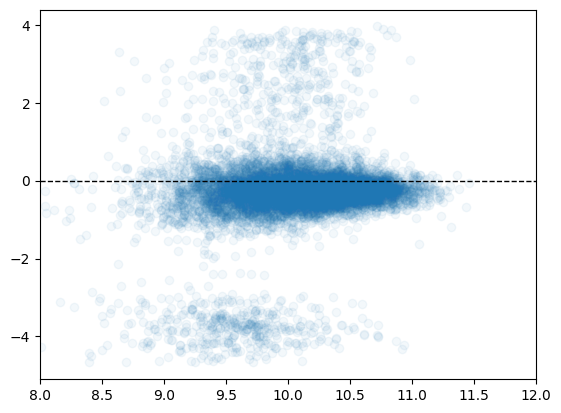

In [46]:
plt.scatter(robust_dps['LOGM'], np.log10(robust_dps['sigma_l']/robust_dps['VD_SL']), alpha=0.05)
plt.axhline(0, color='k', linestyle='--', linewidth=1)
plt.xlim(left=8, right=12)
plt.show()

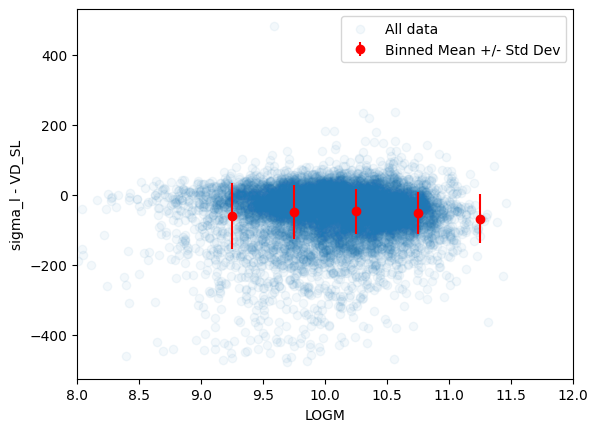

In [47]:
from scipy.stats import binned_statistic

# Bin the data by 'LOGM'
bin_means, bin_edges, binnumber = binned_statistic(robust_dps['LOGM'],
                                                   robust_dps['sigma_l'] - robust_dps['VD_SL'],
                                                   statistic='mean',
                                                   bins=5, range=(9, 11.5))
bin_stds, _, _ = binned_statistic(robust_dps['LOGM'],
                                  robust_dps['sigma_l'] - robust_dps['VD_SL'],
                                  statistic='std',
                                  bins=5, range=(9, 11.5))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Create the plot
# plt.figure(figsize=(8, 6))
# Plot the original scatter data
plt.scatter(robust_dps['LOGM'], robust_dps['sigma_l'] - robust_dps['VD_SL'], alpha=0.05, label='All data')
# Plot the binned means with error bars
plt.errorbar(bin_centers, bin_means, yerr=bin_stds, fmt='o', color='r', label='Binned Mean +/- Std Dev')

# Set plot labels and limits
plt.xlabel('LOGM')
plt.ylabel('sigma_l - VD_SL')
plt.xlim(left=8, right=12)
plt.legend()
plt.show()

In [48]:
low_sep = robust_dps[robust_dps['delta_dv']<60].copy()

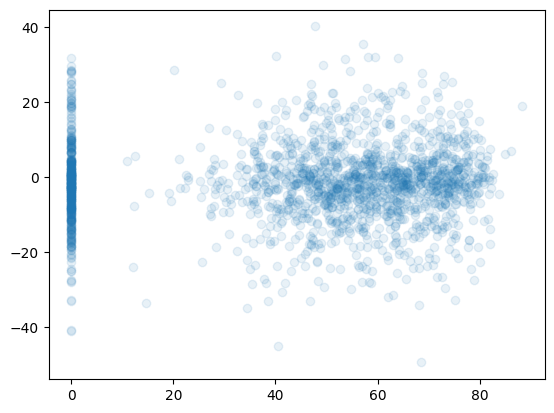

In [49]:
plt.scatter(low_sep['incl'], low_sep['dv_r']+low_sep['dv_l'], alpha=0.1)
plt.show()

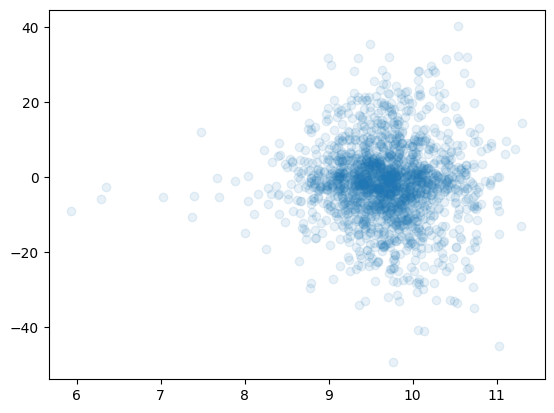

In [50]:
plt.scatter(low_sep['LOGM'], (low_sep['dv_r']+low_sep['dv_l']), alpha=0.1)
plt.show()

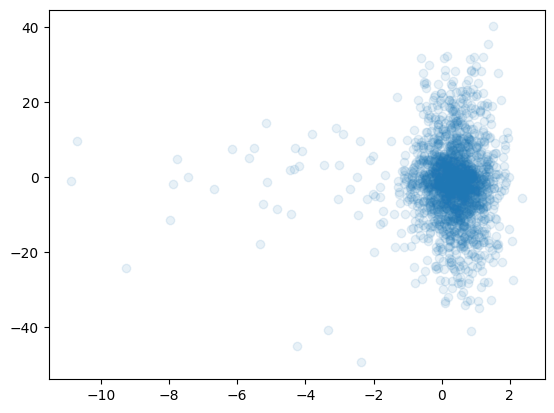

In [51]:
plt.scatter(low_sep['LOGSFR'], (low_sep['dv_r']+low_sep['dv_l']), alpha=0.1)
plt.show()

In [52]:
high_sep = robust_dps[robust_dps['delta_dv']>=60].copy()

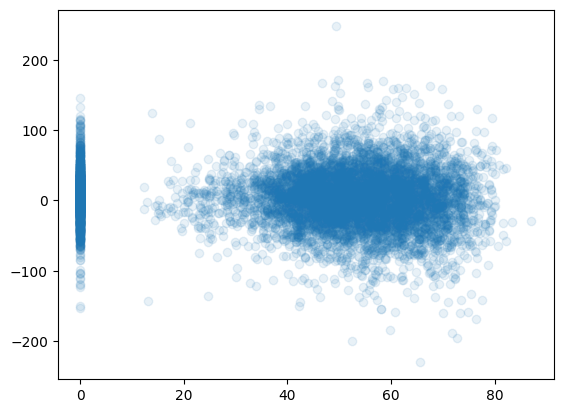

In [53]:
plt.scatter(high_sep['incl'], (high_sep['dv_r']+high_sep['dv_l']), alpha=0.1)
plt.show()

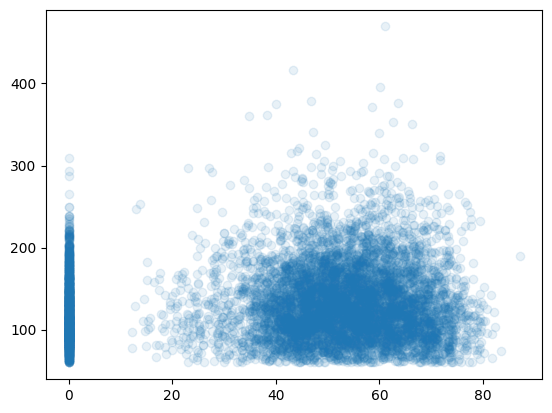

In [54]:
plt.scatter(high_sep['incl'], high_sep['delta_dv'], alpha=0.1)
plt.show()

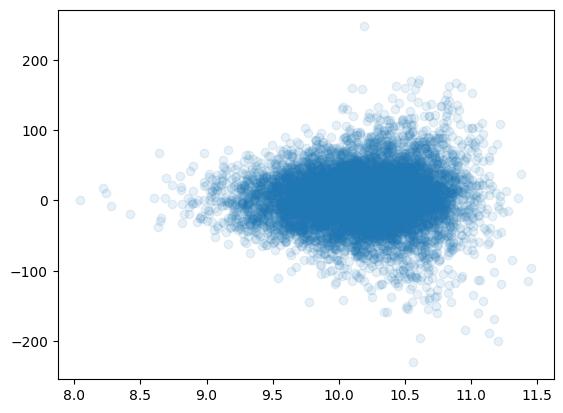

In [55]:
plt.scatter(high_sep['LOGM'], (high_sep['dv_r']+high_sep['dv_l']), alpha=0.1)
plt.show()

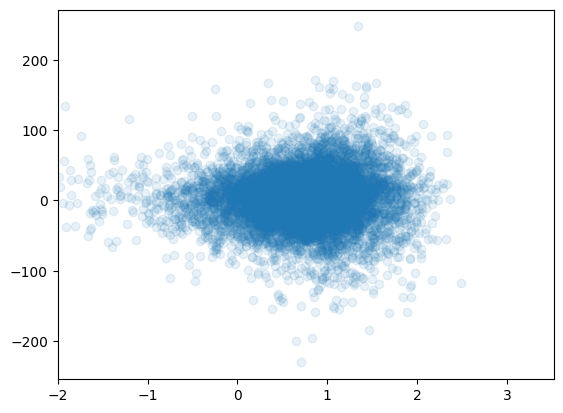

In [56]:
plt.scatter(high_sep['LOGSFR'], (high_sep['dv_r']+high_sep['dv_l']), alpha=0.1)
plt.xlim(left=-2)
plt.show()

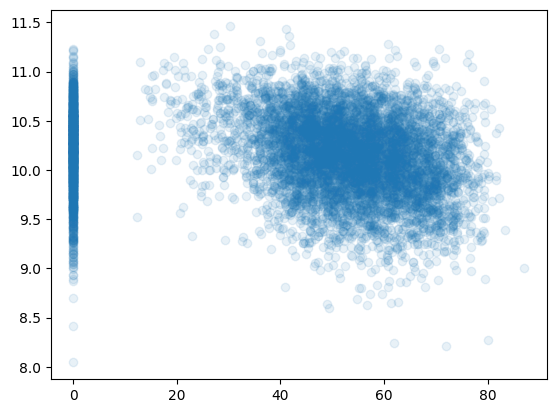

In [57]:
plt.scatter(high_sep['incl'], high_sep['LOGM'], alpha=0.1)
plt.show()

In [58]:
robust_dps.columns

Index(['TARGETID', 'RA', 'DEC', 'Z', 'LOGM', 'LOGSFR', 'dv_r', 'dv_l',
       'sigma_r', 'sigma_l', 'sigma_1comp', 'p_value', 'OII3726_dp',
       'OII3729_dp', 'Hbeta_dp', 'OIII4959_dp', 'OIII5007_dp', 'NII6548_dp',
       'Halpha_dp', 'NII6583_dp', 'SII6716_dp', 'SII6731_dp', 'OII3726_rank',
       'OII3729_rank', 'Hbeta_rank', 'OIII4959_rank', 'OIII5007_rank',
       'NII6548_rank', 'Halpha_rank', 'NII6583_rank', 'SII6716_rank',
       'SII6731_rank', 'dp_count', 'BPT_class', 'MORPHTYPE', 'SERSIC',
       'SHAPE_R', 'VD_SL', 'incl', 'delta_dv', 'width_ratio', 'flux_ratio',
       'BPT_class_str'],
      dtype='object')

/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_42317/969160976.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  corr_df['dv_l'] = -corr_df['dv_l']  # Flip dv_l to make it more intuitive for correlation


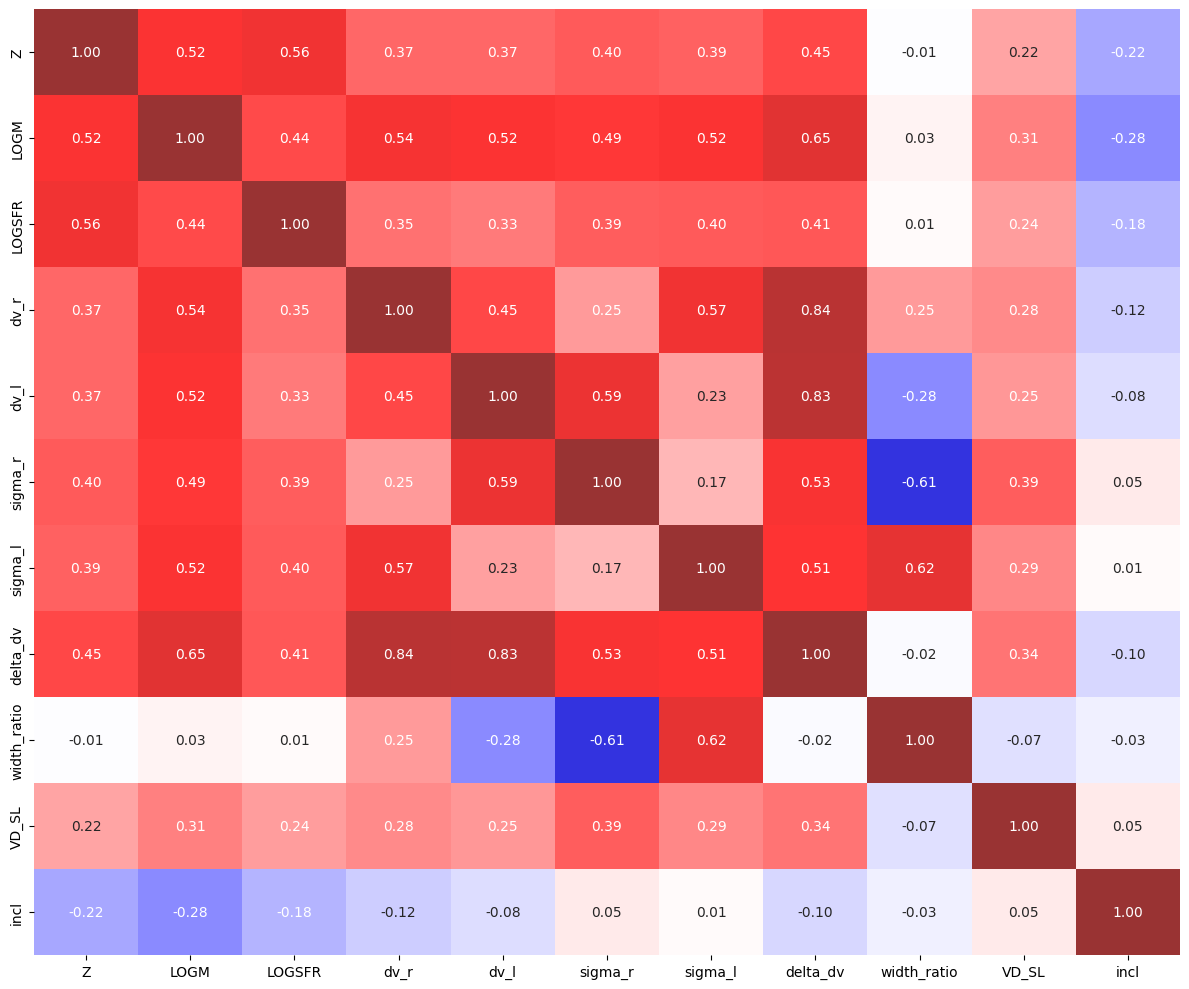

In [59]:
import seaborn as sns

# Select numerical columns for correlation matrix
corr_df = robust_dps[['Z', 'LOGM', 'LOGSFR', 'dv_r', 'dv_l', 'sigma_r', 'sigma_l', 'delta_dv', 'width_ratio', 'VD_SL', 'incl']]
corr_df['dv_l'] = -corr_df['dv_l']  # Flip dv_l to make it more intuitive for correlation
corr_df = corr_df[corr_df['incl']>1].copy()
# Calculate the correlation matrix
correlation_matrix = corr_df.corr(method='spearman')

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap((correlation_matrix), annot=True, cmap='seismic', fmt=".2f", vmin=-1, vmax=1, alpha=0.8, cbar=False)
# plt.title('Correlation Matrix of Galaxy Properties')
plt.tight_layout()
# plt.savefig('./figures/corr_matrix_spearman.png')
plt.show()

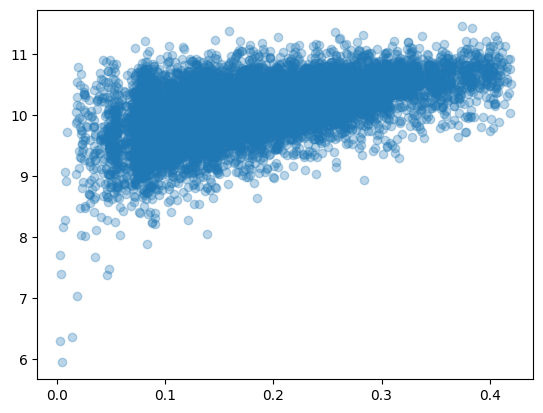

In [60]:
plt.scatter(robust_dps['Z'], robust_dps['LOGM'], alpha=0.3)
plt.show()

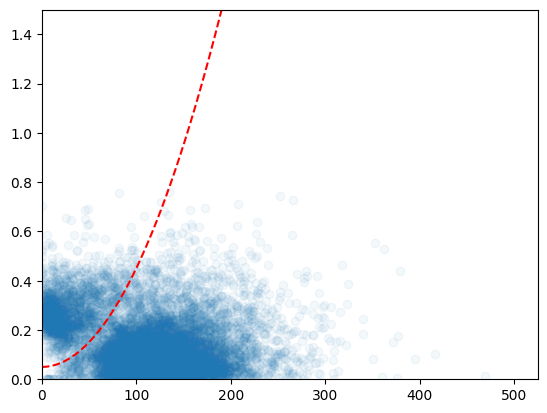

In [61]:
x = np.linspace(0, 500, 100)
y = 4e-5 * x**2 + 0.05

plt.scatter(robust_dps['delta_dv'], np.abs(np.log10(robust_dps['width_ratio'])), alpha=0.05)
plt.plot(x, y, color='r', linestyle='--')
# plt.axvline(60, color='r', linestyle='--')
# plt.axhline(0.1, color='r', linestyle='--')
plt.xlim(left=0)
plt.ylim(bottom=0, top=1.5)
plt.show()

In [62]:
cake_dps = robust_dps[4e-5 * robust_dps['delta_dv']**2 + 0.05 < np.abs(np.log10(robust_dps['width_ratio']))].copy()
horn_dps = robust_dps[4e-5 * robust_dps['delta_dv']**2 + 0.05 > np.abs(np.log10(robust_dps['width_ratio']))].copy()

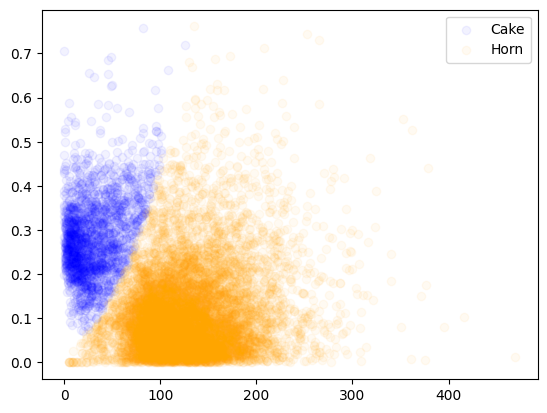

In [63]:
plt.scatter(cake_dps['delta_dv'], np.abs(np.log10(cake_dps['width_ratio'])), alpha=0.05, color='blue', label='Cake')
plt.scatter(horn_dps['delta_dv'], np.abs(np.log10(horn_dps['width_ratio'])), alpha=0.05, color='orange', label='Horn')
plt.legend()
plt.show()

In [64]:
print(cake_dps['MORPHTYPE'].value_counts(normalize=True))
print(len(cake_dps))

MORPHTYPE
SER    0.627203
REX    0.227423
EXP    0.094163
DEV    0.050110
PSF    0.001101
Name: proportion, dtype: float64
1816


In [65]:
print(horn_dps['MORPHTYPE'].value_counts(normalize=True))
print(len(horn_dps))

MORPHTYPE
SER    0.642545
REX    0.225593
EXP    0.098572
DEV    0.032818
PSF    0.000472
Name: proportion, dtype: float64
8471


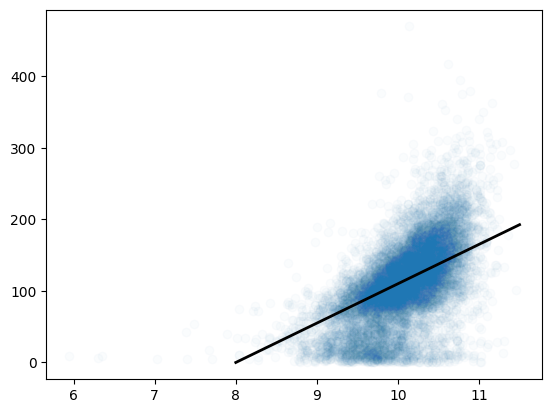

In [66]:
plt.scatter(robust_dps['LOGM'], robust_dps['delta_dv'], alpha=0.02)
x = np.linspace(8, 11.5, 100)
y = 55*(x-9)+55
plt.plot(x, y, color='black', lw=2)
plt.show()

In [67]:
len(merger_cand)

97

In [68]:
merger_cand.sort_values(by='SHAPE_R', ascending=True).head(30)

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,dv_r,dv_l,sigma_r,sigma_l,...,BPT_class,MORPHTYPE,SERSIC,SHAPE_R,VD_SL,incl,delta_dv,width_ratio,flux_ratio,BPT_class_str
12646,39627781868359233,189.667679,-0.128895,0.204595,9.150351,1.288560,36.543297,-19.597082,51.518414,186.876312,...,8,REX,1.000000,0.252451,462.040009,0.000000,56.140381,3.166814,1.191904e+00,double COMP
12278,39627781725753388,181.210297,-0.199903,0.119530,9.546997,0.146538,4.180271,-12.520831,38.934639,156.377640,...,32,REX,1.000000,0.306086,72.820000,0.000000,16.701103,3.144483,4.105884e-01,double AGN
10237,39627775648208586,178.990906,-0.403864,0.250296,10.410080,-0.460224,17.626839,-121.417099,114.924278,14.858010,...,257,REX,1.000000,0.363201,86.470001,0.000000,139.043945,0.276445,4.333300e-01,SF+uncertain
8601,39627769738430225,186.589813,-0.781932,0.284080,10.399223,1.589749,118.075905,-17.887184,25.857386,123.508392,...,5,REX,1.000000,0.375545,146.039993,0.000000,135.963089,3.296644,1.614137e+00,SF+COMP
18677,39627800235214582,204.327087,0.621960,0.276975,10.449203,1.105227,57.241360,-86.844810,129.849426,29.931814,...,5,REX,1.000000,0.400948,176.509995,0.000000,144.086166,0.311407,1.507587e+00,SF+COMP
6577,39627763639911175,183.029068,-1.072288,0.113915,9.275297,1.141646,69.790733,-40.458675,206.817886,60.837109,...,8,REX,1.000000,0.438636,124.989998,0.000000,110.249405,0.330058,1.453059e+00,double COMP
24244,39627818392356897,206.583344,1.331737,0.315747,10.412442,0.004569,120.567566,-14.205716,27.211605,222.514862,...,272,REX,1.000000,0.444960,43.939999,0.000000,134.773285,5.767851,1.868337e+00,AGN+uncertain
14434,39627787878793632,187.775330,0.003754,0.259691,10.396967,0.844448,103.677071,-25.763489,11.199703,146.351105,...,32,REX,1.000000,0.569034,81.290001,0.000000,129.440552,4.798896,1.766668e+00,double AGN
20972,39627806497312462,217.668640,0.758469,0.298289,10.569155,1.370790,142.112961,-25.257065,27.721432,129.024994,...,257,SER,2.738561,0.608917,94.230003,52.274220,167.370026,3.343129,2.055580e+00,SF+uncertain
7932,39627764214535092,217.463226,-1.024473,0.354969,10.606314,1.486107,118.703079,-32.677063,26.431267,154.461212,...,260,REX,1.000000,0.628577,81.199997,0.000000,151.380142,4.152743,1.228877e+00,COMP+uncertain


In [69]:
merger_cand[merger_cand['TARGETID']==39627769717458009]

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,dv_r,dv_l,sigma_r,sigma_l,...,BPT_class,MORPHTYPE,SERSIC,SHAPE_R,VD_SL,incl,delta_dv,width_ratio,flux_ratio,BPT_class_str
8547,39627769717458009,185.297592,-0.786711,0.209338,10.576923,1.014431,195.612762,-157.502609,33.272694,157.301987,...,257,SER,0.614774,1.670016,397.320007,62.61895,353.115356,3.564128,0.545424,SF+uncertain


In [70]:
print(merger_cand['MORPHTYPE'].value_counts(normalize=True))

MORPHTYPE
SER    0.690722
REX    0.154639
DEV    0.082474
EXP    0.072165
Name: proportion, dtype: float64


In [71]:
# for i in range(len(merger_cand)):
#     ra, dec = merger_cand.iloc[i][['RA', 'DEC']]
#     r = merger_cand.iloc[i]['SHAPE_R']
#     if r < 1:
#         image_link(ra, dec, side_arcmin=0.3, plot=False, save_image=True, fname=f"./images/{merger_cand.iloc[i]['TARGETID']}_image.jpg")
#     else:
#         image_link(ra, dec, side_arcmin=0.5/3*r, plot=False, save_image=True, fname=f"./images/{merger_cand.iloc[i]['TARGETID']}_image.jpg")

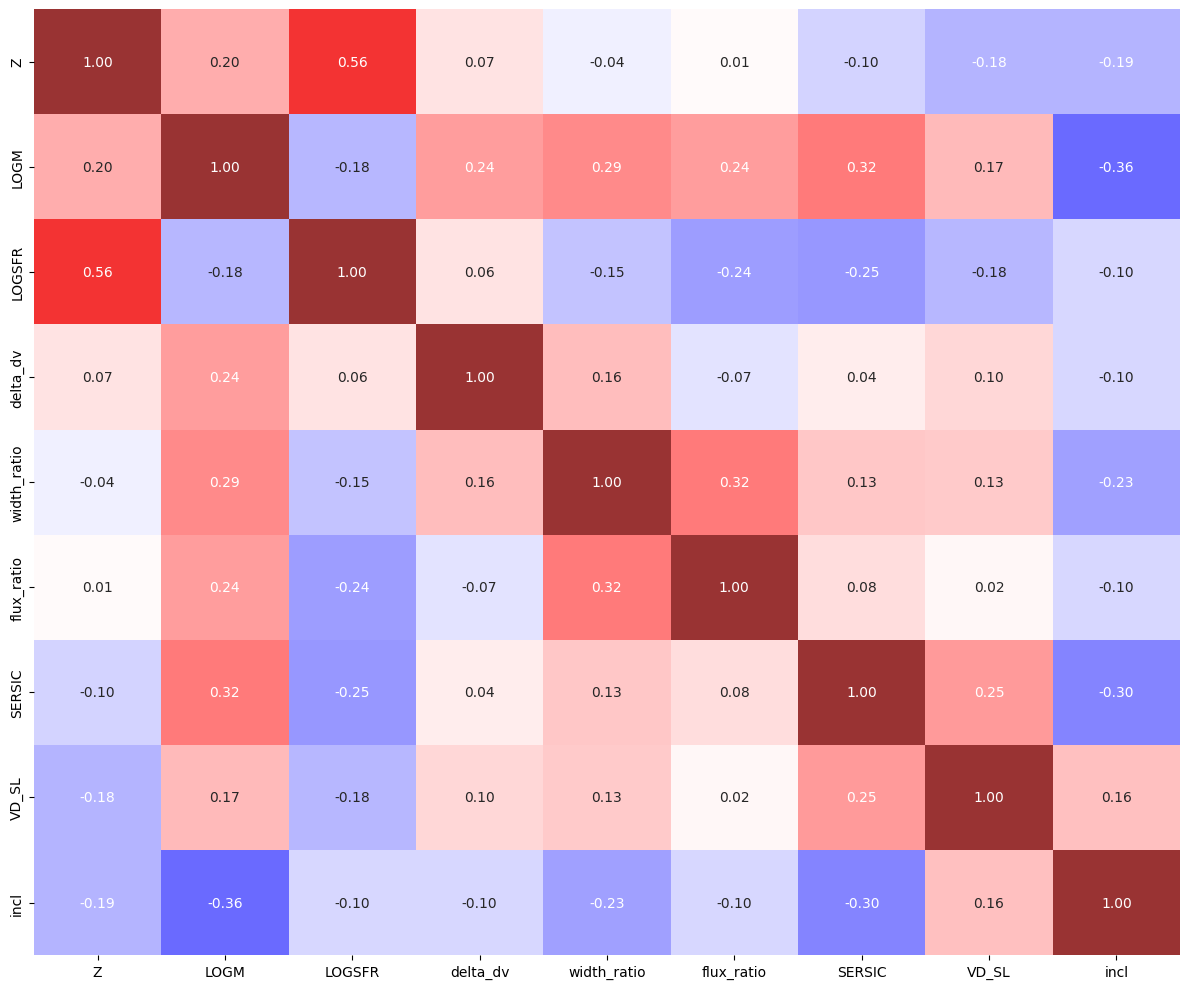

In [72]:
# Select numerical columns for correlation matrix
corr_df = merger_cand[['Z', 'LOGM', 'LOGSFR', 'delta_dv', 'width_ratio', 'flux_ratio', 'SERSIC', 'VD_SL', 'incl']]
corr_df = corr_df[corr_df['incl']>1].copy()
# Calculate the correlation matrix
correlation_matrix = corr_df.corr(method='spearman')

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap((correlation_matrix), annot=True, cmap='seismic', fmt=".2f", vmin=-1, vmax=1, alpha=0.8, cbar=False)
# plt.title('Correlation Matrix of Galaxy Properties')
plt.tight_layout()
# plt.savefig('./figures/corr_matrix_spearman.png')
plt.show()

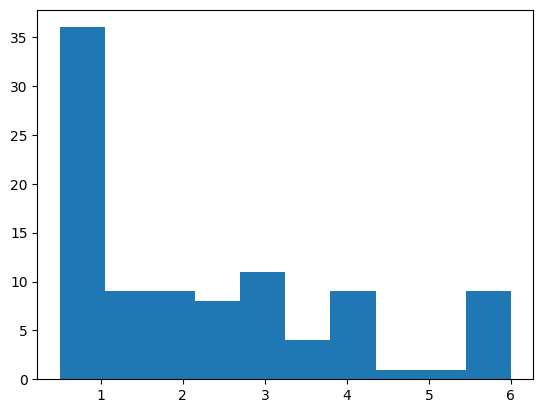

In [73]:
plt.hist(merger_cand['SERSIC'])
plt.show()

In [74]:
merger_cand.sort_values(by='SERSIC', ascending=True).head(20)

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,dv_r,dv_l,sigma_r,sigma_l,...,BPT_class,MORPHTYPE,SERSIC,SHAPE_R,VD_SL,incl,delta_dv,width_ratio,flux_ratio,BPT_class_str
751,39627740042759487,216.649796,-1.998467,0.275597,10.619296,1.140777,6.201106e+00,-28.413815,158.372818,30.509235,...,260,SER,0.500000,1.797086,83.599998,66.339720,34.614922,0.260009,0.521882,COMP+uncertain
20151,39627806132409690,195.980347,0.649483,0.371827,10.268726,1.929244,3.105450e+01,-18.895102,176.464478,32.402836,...,17,SER,0.500000,1.141954,187.059998,53.776978,49.949604,0.235023,1.407273,SF+AGN
3391,39627751757448774,194.821686,-1.573625,0.168504,10.665784,1.110838,6.288541e+01,-32.761971,169.955917,47.945038,...,17,SER,0.535460,5.108536,154.229996,62.444730,95.647377,0.331228,1.615363,SF+AGN
21732,39627812037988321,187.943954,0.981470,0.146044,10.290135,1.085277,1.172502e+02,-20.610270,18.417942,106.767426,...,257,SER,0.567813,2.227698,109.349998,77.917490,137.860474,3.026485,2.629280,SF+uncertain
23913,39627818258140974,198.685837,1.363228,0.387003,10.232123,1.754935,1.968525e+01,-75.585831,105.020409,18.836216,...,17,SER,0.585539,1.178145,173.759995,56.940475,95.271080,0.299081,0.652141,SF+AGN
9716,39627770195609133,213.817230,-0.687208,0.289668,10.538917,1.497841,4.286530e+01,-2.720849,18.169847,148.472198,...,2,SER,0.595702,1.254058,146.250000,47.692234,45.586143,4.491210,2.023730,double SF
8547,39627769717458009,185.297592,-0.786711,0.209338,10.576923,1.014431,1.956128e+02,-157.502609,33.272694,157.301987,...,257,SER,0.614774,1.670016,397.320007,62.618950,353.115356,3.564128,0.545424,SF+uncertain
16307,39627793914401399,187.744080,0.175818,0.308183,9.544332,1.400752,3.566384e+01,-146.627213,47.095245,170.952255,...,257,SER,0.624204,2.219597,163.270004,56.258330,182.291046,3.163625,0.399092,SF+uncertain
13710,39627782342316475,217.965042,-0.348968,0.225808,10.375807,0.856372,1.196971e-25,-0.571019,5.738192,97.940666,...,17,SER,0.634986,1.971905,218.100006,70.277400,0.571019,3.372976,2.050301,SF+AGN
22350,39627812323201636,204.966431,1.032065,0.229658,10.162036,1.671521,9.137037e+00,-22.265766,193.467255,32.556675,...,257,SER,0.690886,1.543101,159.139999,68.183205,31.402803,0.225181,0.513848,SF+uncertain


In [75]:
print(robust_dps['BPT_class_str'].value_counts(normalize=True))

BPT_class_str
double SF          0.454554
SF+uncertain       0.368232
SF+COMP            0.045008
COMP+uncertain     0.035482
AGN+uncertain      0.026927
SF+AGN             0.024011
double AGN         0.016429
double COMP        0.016234
COMP+AGN           0.012054
AGN+LINER          0.000389
LINER+uncertain    0.000389
COMP+LINER         0.000194
SF+LINER           0.000097
Name: proportion, dtype: float64


In [76]:
print(robust_dps.sort_values(by='SERSIC', ascending=True).head(500)['BPT_class_str'].value_counts(normalize=True))

BPT_class_str
double SF         0.478
SF+uncertain      0.428
SF+COMP           0.036
SF+AGN            0.034
COMP+uncertain    0.016
COMP+AGN          0.006
AGN+uncertain     0.002
Name: proportion, dtype: float64


In [77]:
print(robust_dps.sort_values(by='SERSIC', ascending=False).head(500)['BPT_class_str'].value_counts(normalize=True))

BPT_class_str
double SF         0.252
SF+uncertain      0.236
SF+COMP           0.118
COMP+uncertain    0.114
double COMP       0.078
double AGN        0.076
AGN+uncertain     0.050
COMP+AGN          0.048
SF+AGN            0.022
AGN+LINER         0.004
COMP+LINER        0.002
Name: proportion, dtype: float64


In [78]:
print(robust_dps[robust_dps['BPT_class_str']=='double AGN']['SERSIC'].describe())

count    169.000000
mean       3.072362
std        1.538947
min        0.778370
25%        1.736270
50%        2.923350
75%        4.000000
max        6.000000
Name: SERSIC, dtype: float64


In [79]:
print(robust_dps[robust_dps['BPT_class_str']=='double SF']['SERSIC'].describe())

count    4676.000000
mean        1.360338
std         0.954579
min         0.000000
25%         0.956438
50%         1.000000
75%         1.419555
max         6.000000
Name: SERSIC, dtype: float64


In [80]:
print(robust_dps[robust_dps['BPT_class_str']=='SF+AGN']['SERSIC'].describe())

count    247.000000
mean       1.490590
std        1.117606
min        0.500000
25%        0.852986
50%        1.000000
75%        1.651805
max        6.000000
Name: SERSIC, dtype: float64


In [81]:
print(robust_dps[robust_dps['BPT_class_str']=='SF+COMP']['SERSIC'].describe())

count    463.000000
mean       2.013888
std        1.512159
min        0.000000
25%        1.000000
50%        1.243289
75%        2.714173
max        6.000000
Name: SERSIC, dtype: float64


In [82]:
print(robust_dps[robust_dps['BPT_class_str']=='SF+uncertain']['SERSIC'].describe())

count    3788.000000
mean        1.372588
std         0.980866
min         0.000000
25%         0.853326
50%         1.000000
75%         1.446207
max         6.000000
Name: SERSIC, dtype: float64


In [83]:
robust_dps[robust_dps['SERSIC']>4].head(20)

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,dv_r,dv_l,sigma_r,sigma_l,...,BPT_class,MORPHTYPE,SERSIC,SHAPE_R,VD_SL,incl,delta_dv,width_ratio,flux_ratio,BPT_class_str
11,39627739388446113,177.554276,-1.971866,0.083630,10.489296,0.985447,7.177248e+01,-36.191353,34.047718,53.252762,...,5,SER,5.204151,1.424334,123.650002,46.709350,107.963829,1.315391,1.588627,SF+COMP
62,39627739422001687,179.589584,-1.983656,0.188073,10.676142,1.441621,1.537364e+02,-64.202065,51.502804,102.873222,...,20,SER,5.744121,1.003499,220.029999,33.157880,217.938446,1.789974,1.627939,COMP+AGN
135,39627739484919966,183.464890,-1.908738,0.241880,10.447141,1.031131,5.604669e+01,-45.006680,40.716976,51.490784,...,2,SER,6.000000,0.658322,62.230000,41.016933,101.053368,1.180550,1.230967,double SF
156,39627739510081481,184.832153,-1.994655,0.131692,10.883685,0.435817,1.105707e+02,-78.538422,44.400349,95.604019,...,5,SER,5.224558,13.624000,140.080002,52.719150,189.109085,1.838155,0.762312,SF+COMP
252,39627739610743754,190.792465,-1.901006,0.118766,9.964684,0.618813,6.222102e+01,-50.647732,30.460430,46.170429,...,8,SER,6.000000,8.394822,80.150002,54.387154,112.868744,1.266362,1.015377,double COMP
322,39627739673657999,194.528000,-1.879498,0.288526,11.018009,1.502870,1.164522e+02,-133.335831,74.801880,86.067070,...,2,SER,4.392308,1.810741,121.580002,36.186390,249.788025,1.132781,0.792768,double SF
425,39627739753351383,199.346436,-1.955179,0.106683,10.994400,0.165413,9.260150e+01,-71.573753,59.251728,74.345284,...,2,SER,6.000000,8.665271,135.089996,62.175020,164.175262,1.199293,1.097302,double SF
485,39627739799486898,202.019196,-1.890129,0.180293,10.764688,-4.672501,1.968848e+02,-198.321320,169.268784,139.532776,...,32,SER,6.000000,1.987401,205.649994,60.036884,395.206116,0.830593,1.072794,double AGN
511,39627739812074252,202.952118,-1.893506,0.021230,10.149467,-0.072714,2.289152e+01,-100.036812,56.304806,19.125454,...,2,SER,4.666471,7.631039,85.470001,62.195990,122.928329,0.608109,0.433523,double SF
571,39627739862403266,205.880051,-1.882337,0.141648,9.901394,0.608747,4.590889e+01,-18.225620,5.166221,81.740585,...,2,SER,6.000000,1.847516,62.590000,58.396988,64.134506,2.707998,1.728528,double SF


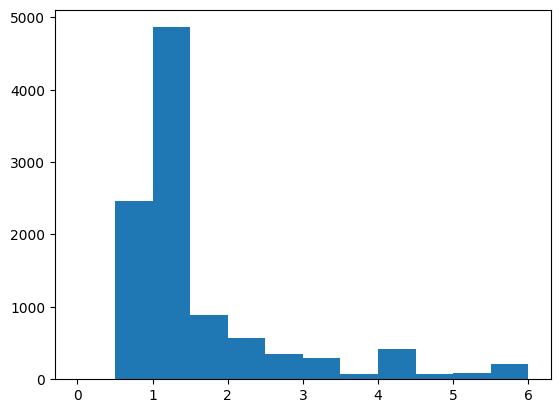

In [84]:
plt.hist(robust_dps['SERSIC'], align='mid', bins=12)
plt.show()

In [85]:
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.cosmology import Planck18 as cosmo

# Define search thresholds
initial_sep_threshold_arcsec = 75.0  # A generous initial search radius in arcseconds
z_sep_upper_threshold = 0.003 # delta_z
# z_sep_lower_threshold = 0.00005 # delta_z
z_sep_lower_threshold = 0.00000 # delta_z

# Define a physical separation threshold in kpc
physical_sep_kpc = 50.0 # kpc

# Create SkyCoord object for all sources for efficient matching
coords = SkyCoord(ra=robust_dps['RA'].values*u.degree, dec=robust_dps['DEC'].values*u.degree)

# Find all pairs within the initial, generous angular separation threshold
idx1, idx2, sep2d, _ = coords.search_around_sky(coords, initial_sep_threshold_arcsec*u.arcsec)

# Filter out self-matches
unique_pairs_mask = idx1 < idx2
idx1 = idx1[unique_pairs_mask]
idx2 = idx2[unique_pairs_mask]
sep2d = sep2d[unique_pairs_mask]

# Create a DataFrame of potential pairs
pair_candidates = pd.DataFrame({
    'idx1': idx1,
    'idx2': idx2,
    'separation_arcsec': sep2d.arcsec
})

# Get redshifts for the pairs
z1 = robust_dps['Z'].values[pair_candidates['idx1']]
z2 = robust_dps['Z'].values[pair_candidates['idx2']]
pair_candidates['z_diff'] = np.abs(z1 - z2)
pair_candidates['z_mean'] = (z1 + z2) / 2.0

# Filter by redshift difference first
close_z_pairs_df = pair_candidates[(pair_candidates['z_diff'] < z_sep_upper_threshold) & (pair_candidates['z_diff'] > z_sep_lower_threshold)].copy()

# Calculate the dynamic angular separation threshold for each pair based on its mean redshift
# This threshold corresponds to the defined physical separation
with np.errstate(divide='ignore'): # Ignore division by zero for z=0
    angular_sep_threshold_deg = (physical_sep_kpc / cosmo.kpc_proper_per_arcmin(close_z_pairs_df['z_mean']) / 60.0).value

# Convert the dynamic threshold to arcseconds
close_z_pairs_df['dynamic_sep_threshold_arcsec'] = angular_sep_threshold_deg * 3600

# Filter pairs based on the dynamic angular separation threshold
close_pairs_df = close_z_pairs_df[close_z_pairs_df['separation_arcsec'] < close_z_pairs_df['dynamic_sep_threshold_arcsec']].reset_index(drop=True)

# Calculate the physical separation in kpc
with np.errstate(divide='ignore'):
    kpc_per_arcmin = cosmo.kpc_proper_per_arcmin(close_pairs_df['z_mean']).value
close_pairs_df['physical_separation_kpc'] = (close_pairs_df['separation_arcsec'] / 60.0) * kpc_per_arcmin

# Add TARGETID to the final close pairs dataframe
close_pairs_df['TARGETID1'] = robust_dps['TARGETID'].values[close_pairs_df['idx1']]
close_pairs_df['TARGETID2'] = robust_dps['TARGETID'].values[close_pairs_df['idx2']]

close_pairs_df['BPT_1'] = robust_dps['BPT_class_str'].values[close_pairs_df['idx1']]
close_pairs_df['BPT_2'] = robust_dps['BPT_class_str'].values[close_pairs_df['idx2']]

close_pairs_df['LOGM_1'] = robust_dps['LOGM'].values[close_pairs_df['idx1']]
close_pairs_df['LOGM_2'] = robust_dps['LOGM'].values[close_pairs_df['idx2']]


close_pairs_df['delta_dv_1'] = robust_dps['delta_dv'].values[close_pairs_df['idx1']]
close_pairs_df['delta_dv_2'] = robust_dps['delta_dv'].values[close_pairs_df['idx2']]

close_pairs_df['dv_l_1'] = robust_dps['dv_l'].values[close_pairs_df['idx1']]
close_pairs_df['dv_l_2'] = robust_dps['dv_l'].values[close_pairs_df['idx2']]

close_pairs_df['dv_r_1'] = robust_dps['dv_r'].values[close_pairs_df['idx1']]
close_pairs_df['dv_r_2'] = robust_dps['dv_r'].values[close_pairs_df['idx2']]

close_pairs_df.drop(columns=['idx1', 'idx2'], inplace=True)
# Display the first few pairs found
print(f"Found {len(close_pairs_df)} close pairs.")
print("Catalog of close pairs:")
close_pairs_df.sort_values(by='physical_separation_kpc', ascending=True)

Found 51 close pairs.
Catalog of close pairs:


,separation_arcsec,z_diff,z_mean,dynamic_sep_threshold_arcsec,physical_separation_kpc,TARGETID1,TARGETID2,BPT_1,BPT_2,LOGM_1,LOGM_2,delta_dv_1,delta_dv_2,dv_l_1,dv_l_2,dv_r_1,dv_r_2
5,2.089046,0.000643,0.080456,31.864392,3.278026,39627751459653321,39627751459653339,SF+COMP,SF+uncertain,10.491512,9.803169,182.261475,63.007874,-79.888115,-17.609392,102.373360,4.539848e+01
8,2.785714,0.000488,0.079605,32.173197,4.329246,39627751891670645,39627751891670649,SF+AGN,double SF,8.794398,9.492950,8.270533,5.879223,-7.699231,-3.260891,0.571301,2.618331e+00
31,4.302928,0.000179,0.075848,33.618354,6.399672,39627782434589057,39627782434589075,double AGN,double AGN,10.085723,10.057607,157.236221,95.595718,-47.745014,-63.395790,109.491203,3.219993e+01
25,2.839601,0.000085,0.129884,20.895203,6.794863,39627781717363964,39627781717363978,double COMP,SF+COMP,9.282807,9.502769,60.244492,10.587145,-47.023136,-9.620452,13.221354,9.666927e-01
45,2.644842,0.000209,0.148921,18.620048,7.102136,39627818065205029,39627818065205040,double SF,double SF,10.084620,9.313739,98.205788,184.201035,-28.585548,-94.882103,69.620239,8.931893e+01
12,3.711042,0.000647,0.111968,23.748027,7.813369,39627758006964708,39627758006964734,SF+uncertain,double SF,10.293689,9.302032,166.078354,12.173874,-31.289288,-6.989560,134.789062,5.184314e+00
9,3.401964,0.000862,0.147467,18.772918,9.060830,39627757579142877,39627757579142891,double SF,SF+uncertain,10.523350,9.147834,172.140503,28.264366,-28.520023,-11.012803,143.620483,1.725156e+01
22,6.346519,0.000390,0.079276,32.294169,9.826107,39627776285742032,39627776285742064,SF+uncertain,double AGN,10.660561,10.422320,198.255997,206.747772,-61.892223,-143.836288,136.363770,6.291148e+01
4,5.728097,0.001612,0.091318,28.432184,10.073262,39627746065780607,39627746065780649,double SF,SF+uncertain,8.396532,9.827850,19.483154,4.830521,-12.131700,-4.683395,7.351455,1.471253e-01
17,3.417802,0.000949,0.179147,16.007988,10.675303,39627770300466665,39627770300466675,SF+uncertain,double SF,10.856450,9.796493,234.345123,376.696960,-83.990700,-197.363495,150.354416,1.793335e+02


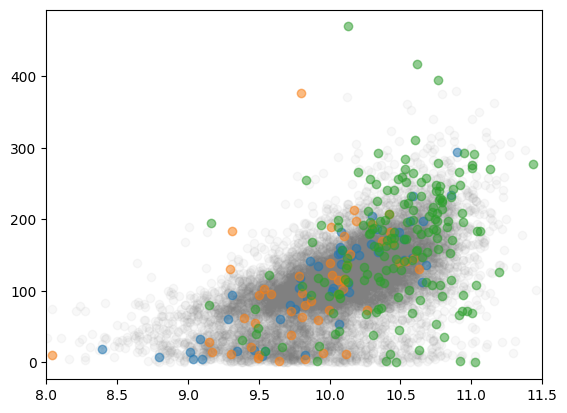

In [86]:
plt.scatter(robust_dps['LOGM'], robust_dps['delta_dv'], alpha=0.05, color='gray')
plt.scatter(close_pairs_df['LOGM_1'], close_pairs_df['delta_dv_1'], alpha=0.5)
plt.scatter(close_pairs_df['LOGM_2'], close_pairs_df['delta_dv_2'], alpha=0.5)
plt.scatter(dAGN['LOGM'], dAGN['delta_dv'], alpha=0.5)
plt.xlim(left=8, right=11.5)
plt.show()

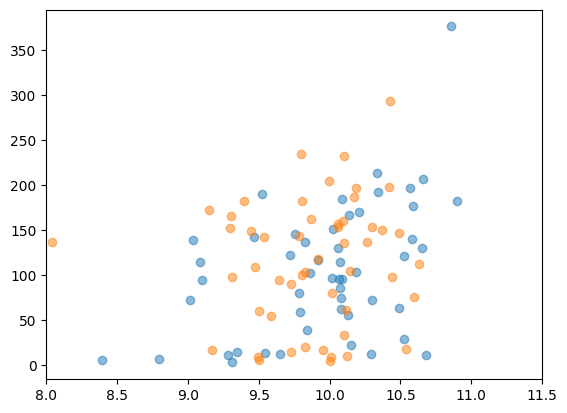

In [87]:
plt.scatter(close_pairs_df['LOGM_1'], close_pairs_df['delta_dv_2'], alpha=0.5)
plt.scatter(close_pairs_df['LOGM_2'], close_pairs_df['delta_dv_1'], alpha=0.5)
plt.xlim(left=8, right=11.5)
plt.show()

In [88]:
print(close_pairs_df.value_counts('BPT_1', normalize=True)*100)

BPT_1
double SF         49.019608
SF+uncertain      27.450980
SF+COMP            7.843137
AGN+uncertain      3.921569
SF+AGN             3.921569
double AGN         3.921569
COMP+uncertain     1.960784
double COMP        1.960784
Name: proportion, dtype: float64


In [89]:
print(close_pairs_df.value_counts('BPT_2', normalize=True)*100)

BPT_2
double SF       52.941176
SF+uncertain    35.294118
double AGN       3.921569
double COMP      3.921569
SF+AGN           1.960784
SF+COMP          1.960784
Name: proportion, dtype: float64


In [90]:
robust_dps[robust_dps['TARGETID']==39627782434589057]

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,dv_r,dv_l,sigma_r,sigma_l,...,BPT_class,MORPHTYPE,SERSIC,SHAPE_R,VD_SL,incl,delta_dv,width_ratio,flux_ratio,BPT_class_str
13923,39627782434589057,223.344742,-0.27844,0.075758,10.085723,0.767816,109.491203,-47.745014,41.212719,60.2644,...,32,SER,1.804471,1.143755,85.139999,55.07008,157.236221,1.295342,1.622313,double AGN


In [91]:
robust_dps[robust_dps['TARGETID']==39627782434589075]

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,dv_r,dv_l,sigma_r,sigma_l,...,BPT_class,MORPHTYPE,SERSIC,SHAPE_R,VD_SL,incl,delta_dv,width_ratio,flux_ratio,BPT_class_str
13924,39627782434589075,223.345337,-0.279477,0.075938,10.057607,-5.990473,32.199932,-63.39579,33.995991,40.875744,...,32,SER,2.639614,0.992112,86.400002,55.22019,95.595718,1.105943,0.598483,double AGN


In [92]:
# dAGN = robust_dps[robust_dps['BPT_class_str']=='double AGN']
# print(len(dAGN))
# for i in range(len(dAGN)):
#     ra, dec = dAGN.iloc[i][['RA', 'DEC']]
#     r = dAGN.iloc[i]['SHAPE_R']
#     if r < 1:
#         image_link(ra, dec, side_arcmin=0.3, plot=False, save_image=True, fname=f"./images/{dAGN.iloc[i]['TARGETID']}_image.jpg")
#     else:
#         image_link(ra, dec, side_arcmin=0.5/3*r, plot=False, save_image=True, fname=f"./images/{dAGN.iloc[i]['TARGETID']}_image.jpg")

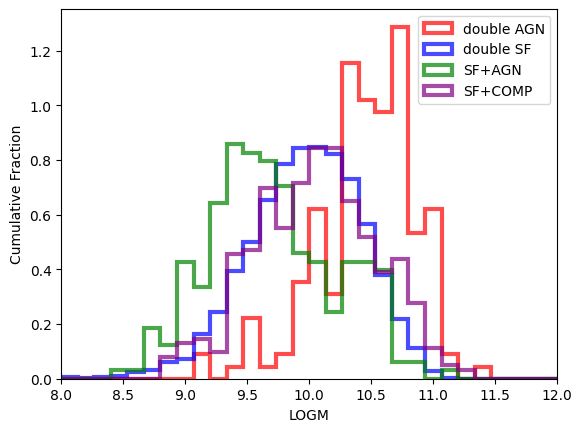

In [93]:
# plt.hist(robust_dps['LOGM'], bins=30, alpha=0.7, color='gray', histtype='step', label='DPS', range=(8, 12), density=True, linewidth=3)
plt.hist(dAGN['LOGM'], bins=30, alpha=0.7, color='red', histtype='step', label='double AGN', range=(8, 12), density=True, linewidth=3)
plt.hist(dSF['LOGM'], bins=30, alpha=0.7, color='blue', histtype='step', label='double SF', range=(8, 12), density=True, linewidth=3)
plt.hist(SF_AGN['LOGM'], bins=30, alpha=0.7, color='green', histtype='step', label='SF+AGN', range=(8, 12), density=True, linewidth=3)
plt.hist(SF_COMP['LOGM'], bins=30, alpha=0.7, color='purple', histtype='step', label='SF+COMP', range=(8, 12), density=True, linewidth=3)
plt.xlim((8, 12))
plt.xlabel('LOGM')
plt.ylabel('Cumulative Fraction')
plt.legend()
plt.show()

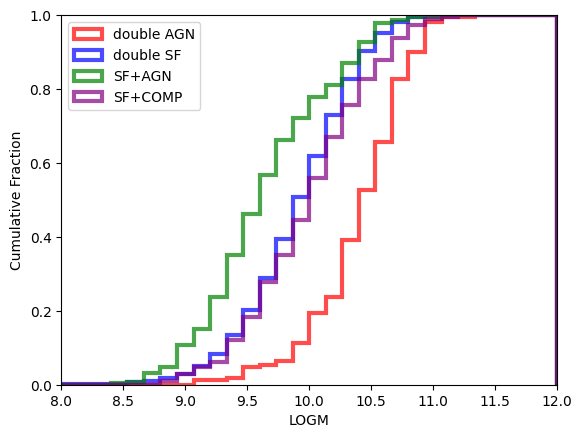

In [94]:
# plt.hist(robust_dps['LOGM'], bins=30, alpha=0.7, color='gray', histtype='step', label='DPS', range=(8, 12), density=True, linewidth=3)
plt.hist(dAGN['LOGM'], bins=30, alpha=0.7, color='red', histtype='step', label='double AGN', range=(8, 12), density=True, linewidth=3, cumulative=True)
plt.hist(dSF['LOGM'], bins=30, alpha=0.7, color='blue', histtype='step', label='double SF', range=(8, 12), density=True, linewidth=3, cumulative=True)
plt.hist(SF_AGN['LOGM'], bins=30, alpha=0.7, color='green', histtype='step', label='SF+AGN', range=(8, 12), density=True, linewidth=3, cumulative=True)
plt.hist(SF_COMP['LOGM'], bins=30, alpha=0.7, color='purple', histtype='step', label='SF+COMP', range=(8, 12), density=True, linewidth=3, cumulative=True)
plt.xlim((8, 12))
plt.ylim((0, 1))
plt.xlabel('LOGM')
plt.ylabel('Cumulative Fraction')
plt.legend()
plt.show()

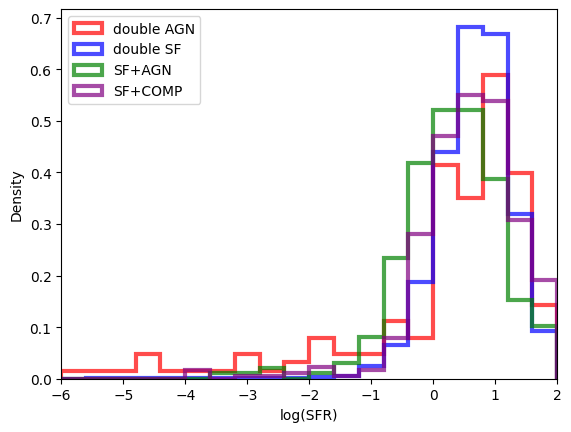

In [95]:
plt.hist(dAGN['LOGSFR'], bins=20, alpha=0.7, color='red', histtype='step', label='double AGN', range=(-6, 2), density=True, linewidth=3)
plt.hist(dSF['LOGSFR'], bins=20, alpha=0.7, color='blue', histtype='step', label='double SF', range=(-6, 2), density=True, linewidth=3)
plt.hist(SF_AGN['LOGSFR'], bins=20, alpha=0.7, color='green', histtype='step', label='SF+AGN', range=(-6, 2), density=True, linewidth=3)
plt.hist(SF_COMP['LOGSFR'], bins=20, alpha=0.7, color='purple', histtype='step', label='SF+COMP', range=(-6, 2), density=True, linewidth=3)
plt.xlim((-6, 2))
plt.xlabel('log(SFR)')
plt.ylabel('Density')
plt.legend()
plt.show()

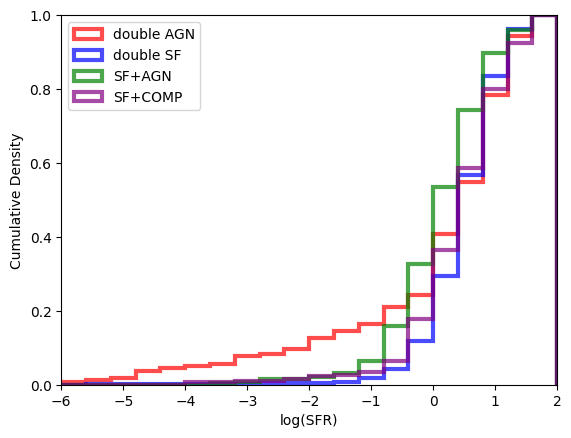

In [96]:
plt.hist(dAGN['LOGSFR'], bins=20, alpha=0.7, color='red', histtype='step', label='double AGN', range=(-6, 2), density=True, linewidth=3, cumulative=True)
plt.hist(dSF['LOGSFR'], bins=20, alpha=0.7, color='blue', histtype='step', label='double SF', range=(-6, 2), density=True, linewidth=3, cumulative=True)
plt.hist(SF_AGN['LOGSFR'], bins=20, alpha=0.7, color='green', histtype='step', label='SF+AGN', range=(-6, 2), density=True, linewidth=3, cumulative=True)
plt.hist(SF_COMP['LOGSFR'], bins=20, alpha=0.7, color='purple', histtype='step', label='SF+COMP', range=(-6, 2), density=True, linewidth=3, cumulative=True)
plt.xlim((-6, 2))
plt.ylim((0, 1))
plt.xlabel('log(SFR)')
plt.ylabel('Cumulative Density')
plt.legend()
plt.show()

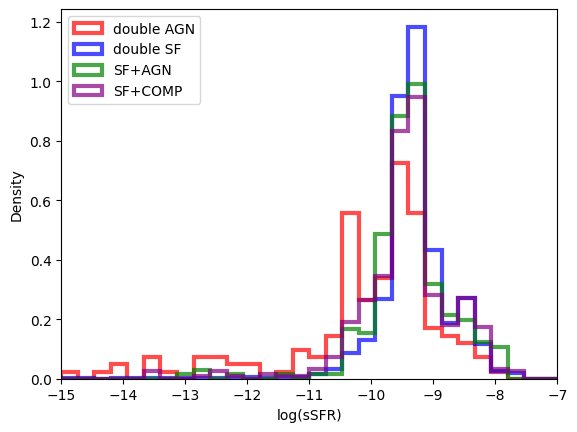

In [97]:
plt.hist(dAGN['LOGSFR']-dAGN['LOGM'], bins=30, alpha=0.7, color='red', histtype='step', label='double AGN', range=(-15,-7), density=True, linewidth=3)
plt.hist(dSF['LOGSFR']-dSF['LOGM'], bins=30, alpha=0.7, color='blue', histtype='step', label='double SF', range=(-15, -7), density=True, linewidth=3)
plt.hist(SF_AGN['LOGSFR']-SF_AGN['LOGM'], bins=30, alpha=0.7, color='green', histtype='step', label='SF+AGN', range=(-15, -7), density=True, linewidth=3)
plt.hist(SF_COMP['LOGSFR']-SF_COMP['LOGM'], bins=30, alpha=0.7, color='purple', histtype='step', label='SF+COMP', range=(-15, -7), density=True, linewidth=3)
plt.xlim((-15, -7))
plt.xlabel('log(sSFR)')
plt.ylabel('Density')
plt.legend()
plt.show()

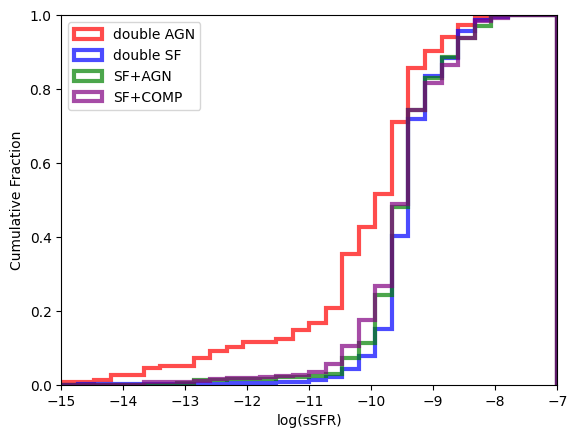

In [98]:
plt.hist(dAGN['LOGSFR']-dAGN['LOGM'], bins=30, alpha=0.7, color='red', histtype='step', label='double AGN', range=(-15,-7), density=True, linewidth=3, cumulative=True)
plt.hist(dSF['LOGSFR']-dSF['LOGM'], bins=30, alpha=0.7, color='blue', histtype='step', label='double SF', range=(-15, -7), density=True, linewidth=3, cumulative=True)
plt.hist(SF_AGN['LOGSFR']-SF_AGN['LOGM'], bins=30, alpha=0.7, color='green', histtype='step', label='SF+AGN', range=(-15, -7), density=True, linewidth=3, cumulative=True)
plt.hist(SF_COMP['LOGSFR']-SF_COMP['LOGM'], bins=30, alpha=0.7, color='purple', histtype='step', label='SF+COMP', range=(-15, -7), density=True, linewidth=3, cumulative=True)
plt.xlim((-15, -7))
plt.ylim((0, 1))
plt.xlabel('log(sSFR)')
plt.ylabel('Cumulative Fraction')
plt.legend()
plt.show()

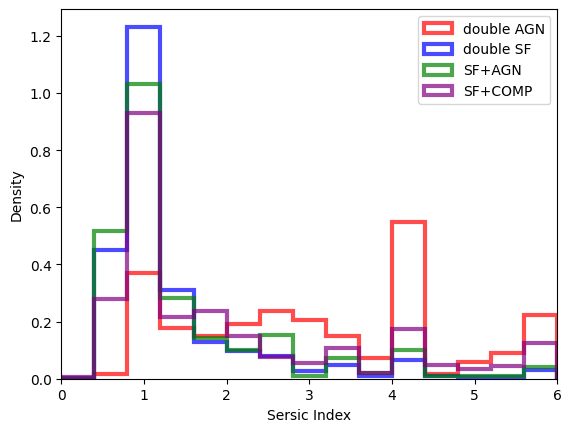

In [99]:
plt.hist(dAGN['SERSIC'], bins=15, alpha=0.7, color='red', histtype='step', label='double AGN', range=(0, 6), density=True, linewidth=3, cumulative=False)
plt.hist(dSF['SERSIC'], bins=15, alpha=0.7, color='blue', histtype='step', label='double SF', range=(0, 6), density=True, linewidth=3, cumulative=False)
plt.hist(SF_AGN['SERSIC'], bins=15, alpha=0.7, color='green', histtype='step', label='SF+AGN', range=(0, 6), density=True, linewidth=3, cumulative=False)
plt.hist(SF_COMP['SERSIC'], bins=15, alpha=0.7, color='purple', histtype='step', label='SF+COMP', range=(0, 6), density=True, linewidth=3, cumulative=False)
plt.xlim((0, 6))
plt.xlabel('Sersic Index')
plt.ylabel('Density')
plt.legend()
plt.show()

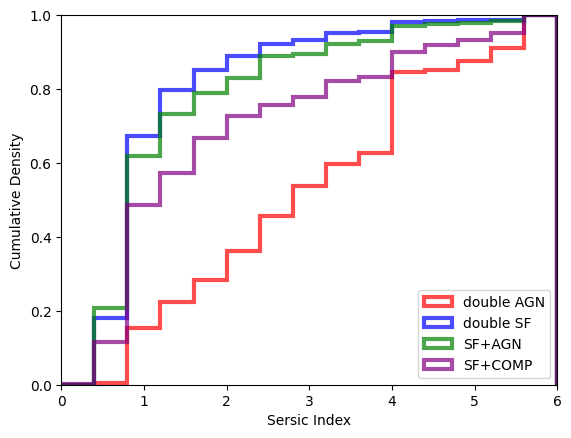

In [100]:
plt.hist(dAGN['SERSIC'], bins=15, alpha=0.7, color='red', histtype='step', label='double AGN', range=(0, 6), density=True, linewidth=3, cumulative=True)
plt.hist(dSF['SERSIC'], bins=15, alpha=0.7, color='blue', histtype='step', label='double SF', range=(0, 6), density=True, linewidth=3, cumulative=True)
plt.hist(SF_AGN['SERSIC'], bins=15, alpha=0.7, color='green', histtype='step', label='SF+AGN', range=(0, 6), density=True, linewidth=3, cumulative=True)
plt.hist(SF_COMP['SERSIC'], bins=15, alpha=0.7, color='purple', histtype='step', label='SF+COMP', range=(0, 6), density=True, linewidth=3, cumulative=True)
plt.xlim((0, 6))
plt.ylim((0, 1))
plt.xlabel('Sersic Index')
plt.ylabel('Cumulative Density')
plt.legend()
plt.show()

In [101]:
dAGN.head(10)

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,dv_r,dv_l,sigma_r,sigma_l,...,BPT_class,MORPHTYPE,SERSIC,SHAPE_R,VD_SL,incl,delta_dv,width_ratio,flux_ratio,BPT_class_str
71,39627739426199525,179.974777,-1.876206,0.228582,10.451921,0.803592,75.128784,-88.730904,41.905041,50.552013,...,32,SER,1.397824,0.945368,117.660004,46.456320,163.859680,1.141400,0.678405,double AGN
358,39627739703019507,196.335449,-1.973153,0.108819,10.260061,-1.218022,47.172050,-20.445967,0.016776,85.924553,...,32,REX,1.000000,0.744918,100.760002,0.000000,67.618019,2.792977,1.667925,double AGN
420,39627739749157642,199.127518,-1.981718,0.267000,10.026224,1.394425,47.032036,-22.158352,142.609802,43.756020,...,32,REX,1.000000,0.412603,161.550003,0.000000,69.190384,0.360168,0.809446,double AGN
485,39627739799486898,202.019196,-1.890129,0.180293,10.764688,-4.672501,196.884781,-198.321320,169.268784,139.532776,...,32,SER,6.000000,1.987401,205.649994,60.036884,395.206116,0.830593,1.072794,double AGN
603,39627739891761764,207.533127,-1.906634,0.252526,10.747873,0.454991,55.953423,-191.842270,70.087547,89.643982,...,32,SER,2.923350,0.835681,141.190002,24.753784,247.795685,1.241787,0.449525,double AGN
868,39627740172782976,224.373001,-1.882365,0.226918,10.522016,0.068074,68.827568,-103.063522,106.421127,46.037846,...,32,SER,5.068029,1.606387,167.300003,60.279830,171.891083,0.496147,0.908827,double AGN
1502,39627745679903179,192.611191,-1.693005,0.131843,9.922876,0.470162,10.756968,-12.079789,0.010062,60.658169,...,32,REX,1.000000,0.952066,49.299999,0.000000,22.836758,2.128715,1.190771,double AGN
1570,39627745705072201,194.235596,-1.852081,0.188789,10.834752,0.480526,104.776138,-93.405357,80.777733,57.090698,...,32,SER,5.722156,1.232811,144.490005,49.380540,198.181488,0.750198,1.488287,double AGN
1732,39627745788953410,199.042908,-1.757193,0.142350,11.017694,-11.650778,115.546295,-175.468597,143.279068,46.059109,...,32,DEV,4.000000,2.593529,165.660004,59.887310,291.014893,0.381961,1.953290,double AGN
1885,39627745843482568,202.438095,-1.811051,0.129681,10.848991,1.086985,51.352539,-101.380653,86.754906,42.816654,...,32,SER,3.839413,1.473427,126.089996,27.570225,152.733185,0.579541,0.799201,double AGN


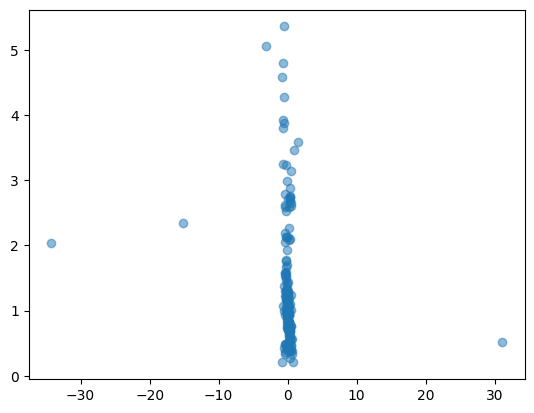

In [102]:
Mr_Ml_ratio = np.log10(-dAGN['dv_l']/dAGN['dv_r'])
plt.scatter(Mr_Ml_ratio, dAGN['width_ratio'], alpha=0.5)
plt.show()

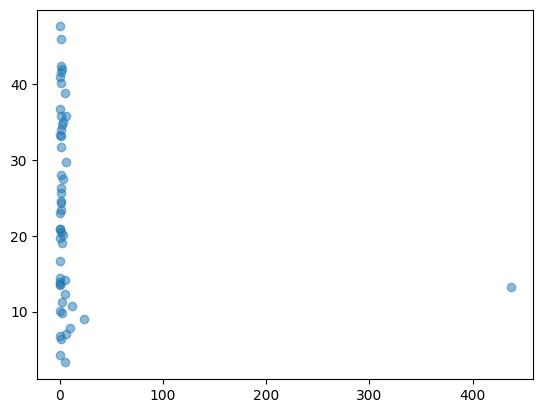

In [103]:
plt.scatter(10**(close_pairs_df['LOGM_1']-close_pairs_df['LOGM_2']), close_pairs_df['physical_separation_kpc'], alpha=0.5)

plt.show()

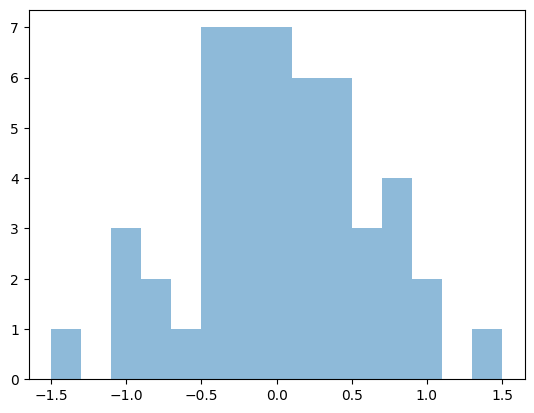

In [104]:
plt.hist((close_pairs_df['LOGM_1']-close_pairs_df['LOGM_2']), bins=15, alpha=0.5, range=(-1.5, 1.5))
plt.show()

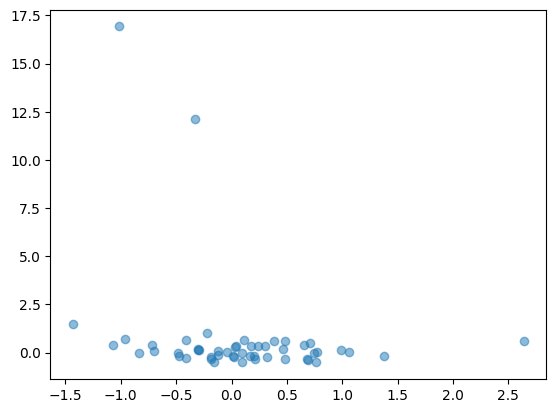

In [105]:
plt.scatter(close_pairs_df['LOGM_1']-close_pairs_df['LOGM_2'], np.log10(-close_pairs_df['dv_l_2']/close_pairs_df['dv_r_2']), alpha=0.5)
plt.show()

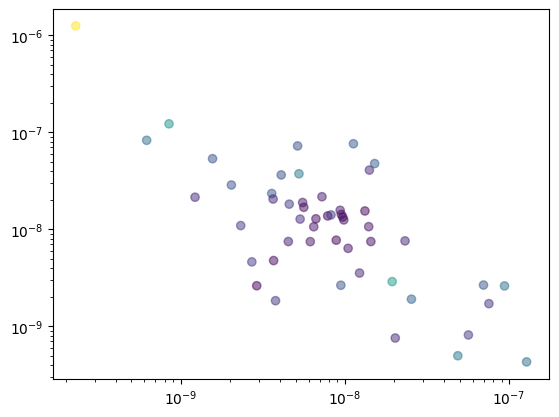

In [114]:

plt.scatter(close_pairs_df['delta_dv_2']/10**close_pairs_df['LOGM_1'], close_pairs_df['delta_dv_1']/10**close_pairs_df['LOGM_2'], alpha=0.5, c=np.abs(close_pairs_df['LOGM_1']-close_pairs_df['LOGM_2']), cmap='viridis')
plt.xscale('log')
plt.yscale('log')
# plt.savefig('./figures/Feb25/delta_dv_scatter.png')
plt.show()

In [107]:
from scipy.stats import spearmanr

# Prepare the data from the previous plot
x_data = np.log10(close_pairs_df['delta_dv_2'] / 10**close_pairs_df['LOGM_1'])
y_data = np.log10(close_pairs_df['delta_dv_1'] / 10**close_pairs_df['LOGM_2'])

# Remove any non-finite values to ensure correlation can be calculated
valid_data = pd.DataFrame({'x': x_data, 'y': y_data}).dropna()
valid_data = valid_data[np.isfinite(valid_data).all(1)]


# Calculate Spearman correlation
correlation, p_value = spearmanr(valid_data['x'], valid_data['y'])

print(f"Spearman Correlation: {correlation:.5f}")
print(f"P-value: {p_value:.5f}")

Spearman Correlation: -0.56398
P-value: 0.00002


In [108]:
from scipy.stats import pearsonr

# The valid_data DataFrame is already prepared and cleaned in the previous cell.
# Calculate Pearson correlation
correlation, p_value = pearsonr(valid_data['x'], valid_data['y'])

print(f"Pearson Correlation: {correlation:.6f}")
print(f"P-value: {p_value:.6f}")

Pearson Correlation: -0.725284
P-value: 0.000000


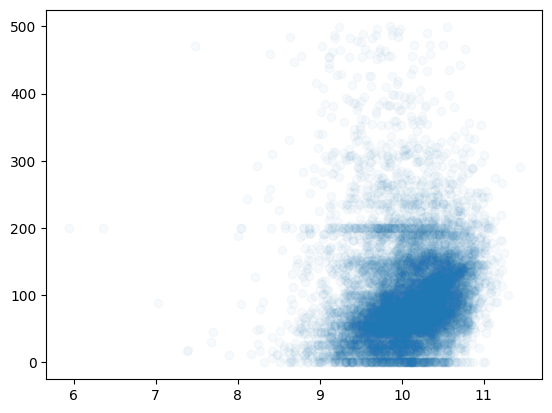

In [118]:
plt.scatter(robust_dps[robust_dps['LOGSFR']>-2]['LOGM'], robust_dps[robust_dps['LOGSFR']>-2]['VD_SL'], alpha=0.03)
plt.show()